## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_stand_3"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "standard"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


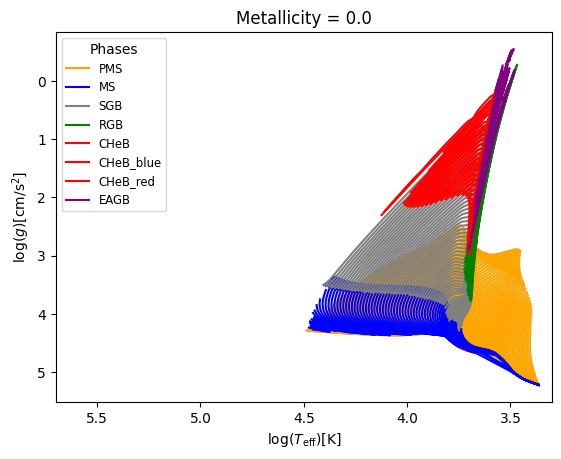

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


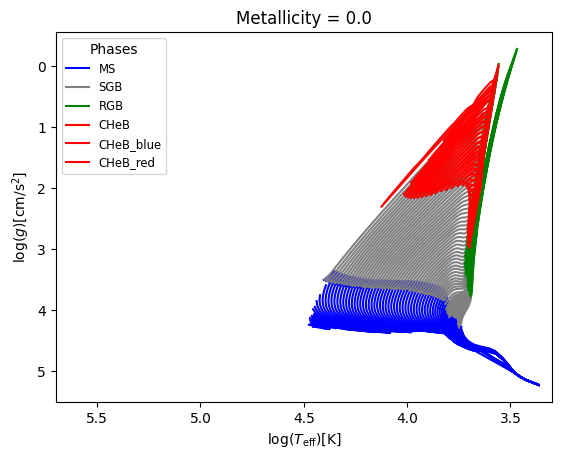

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,6.80001,4.1048,4.436,1.0,-0.25,2.687,0.215638
1,6.85001,4.1046,4.435,1.0,-0.25,2.687,0.216166
2,6.90001,4.1043,4.434,1.0,-0.25,2.687,0.216694
3,6.90001,4.1083,4.434,1.0,-0.25,2.725,0.220108
4,6.95001,4.1041,4.433,1.0,-0.25,2.687,0.217221
...,...,...,...,...,...,...,...
243958,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
243959,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
243960,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
243961,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


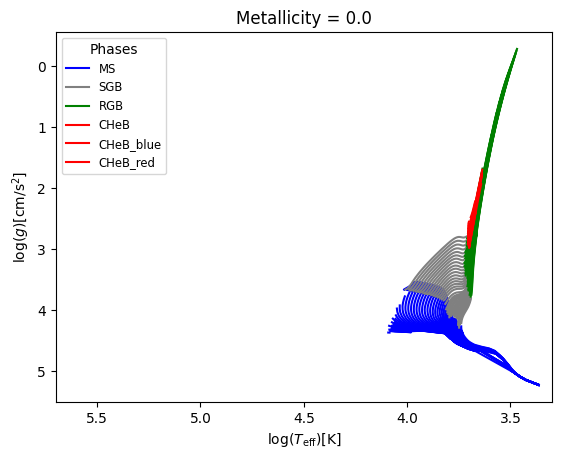

In [8]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6], "Mass" : ("<", 3)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [9]:
print_all_uniques(phase_mass_filtered_iso_df)

logAge  : Range : 6.8 - 10.25, Mean : 9.4807, Median : 9.5

logTe  : Range : 3.36 - 4.1907, Mean : 3.732, Median : 3.7204

logg  : Range : -0.38 - 5.345, Mean : 2.8946, Median : 2.504

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 2.999, Mean : 1.3031, Median : 1.178

Rpol  : Range : -0.98 - 2.3632, Mean : 0.8085, Median : 1.0017



In [10]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 2.999
Median value in train data for the Mass parameter: 1.179
Mean value in train data for the Mass parameter: 1.3036826782239908

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.363235804483694
Median value in train data for the Rpol parameter: 1.0017337128090005
Mean value in train data for the Rpol parameter: 0.8081824956202829

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 2.999
Median value in test data for the Mass parameter: 1.174
Mean value in test data for the Mass parameter: 1.3014723647751307

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.336259552014193
Median value in test data for the Rpol parameter: 1.0021660617565078
Mean value in test data for the Rpol parameter: 0.8093982982620794

(182972, 4) (60991, 4)
(182972, 2) (60991, 2)


## Model training

### Linear regression

In [11]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_stand_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.6611637557456101
  RMSE :  0.37973772350498736
  MAE :  0.28802763816317883
  MedAE :  0.23494432335652837
  CORR :  0.8695920943962192
  MAX_ER :  1.6127551731544196
  Percentiles : 
    75th percentile :  0.38605043582482373
    90th percentile :  0.6141982436381904
    95th percentile :  0.8110251649149962
    99th percentile :  1.140653939672698

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9233322195098886
  RMSE :  0.27098534386782847
  MAE :  0.21390872950774675
  MedAE :  0.17897850878095478
  CORR :  0.9647416834643497
  MAX_ER :  0.8713407094858767
  Percentiles : 
    75th percentile :  0.30200874580720005
    90th percentile :  0.45789455755944325
    95th percentile :  0.5572122378871376
    99th percentile :  0.70009781611

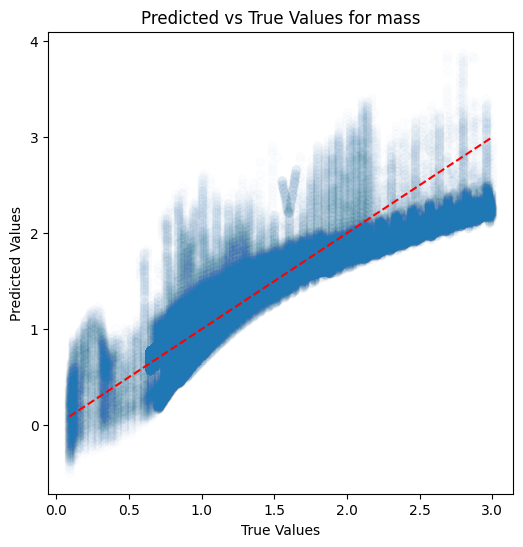

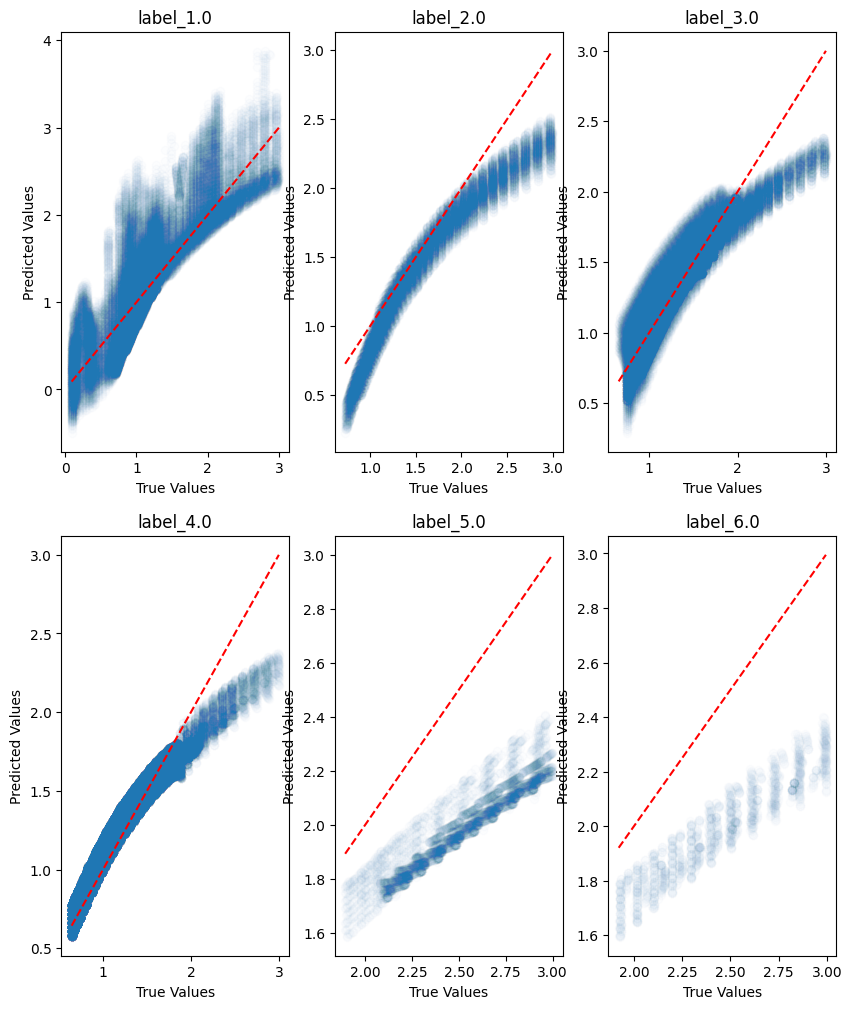

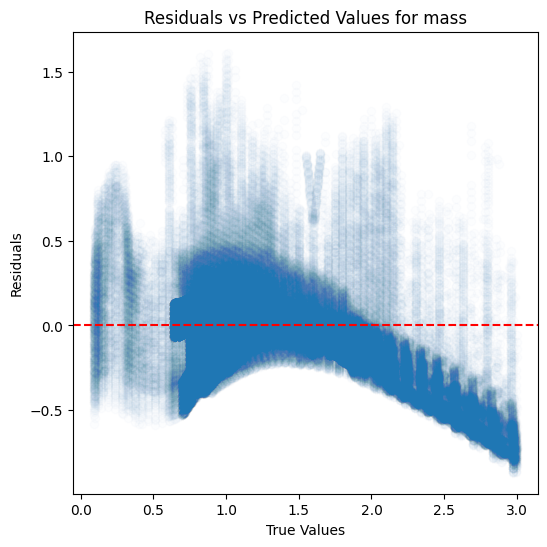

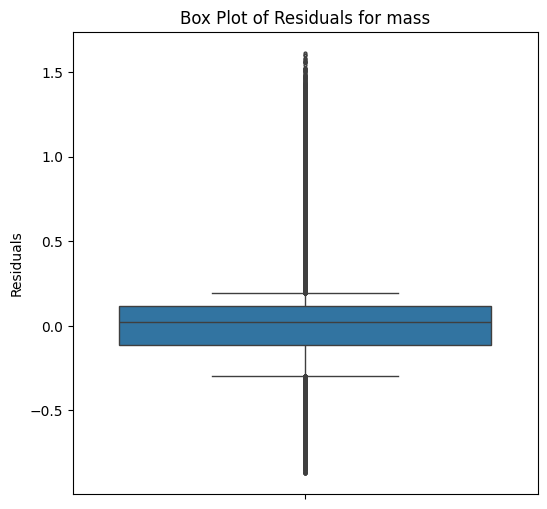

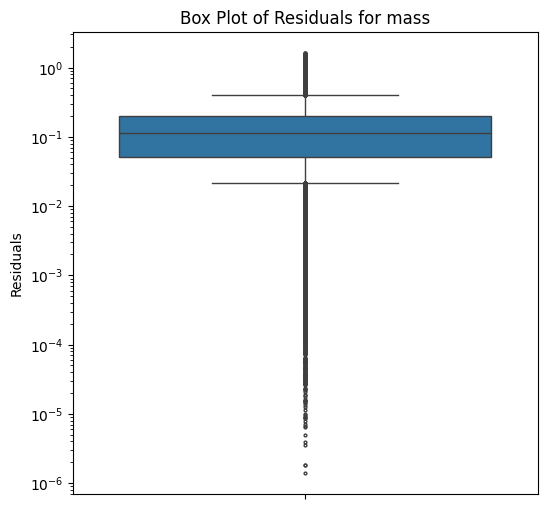

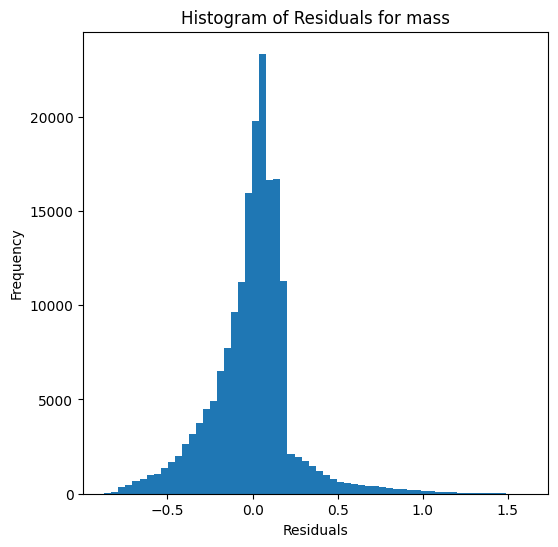

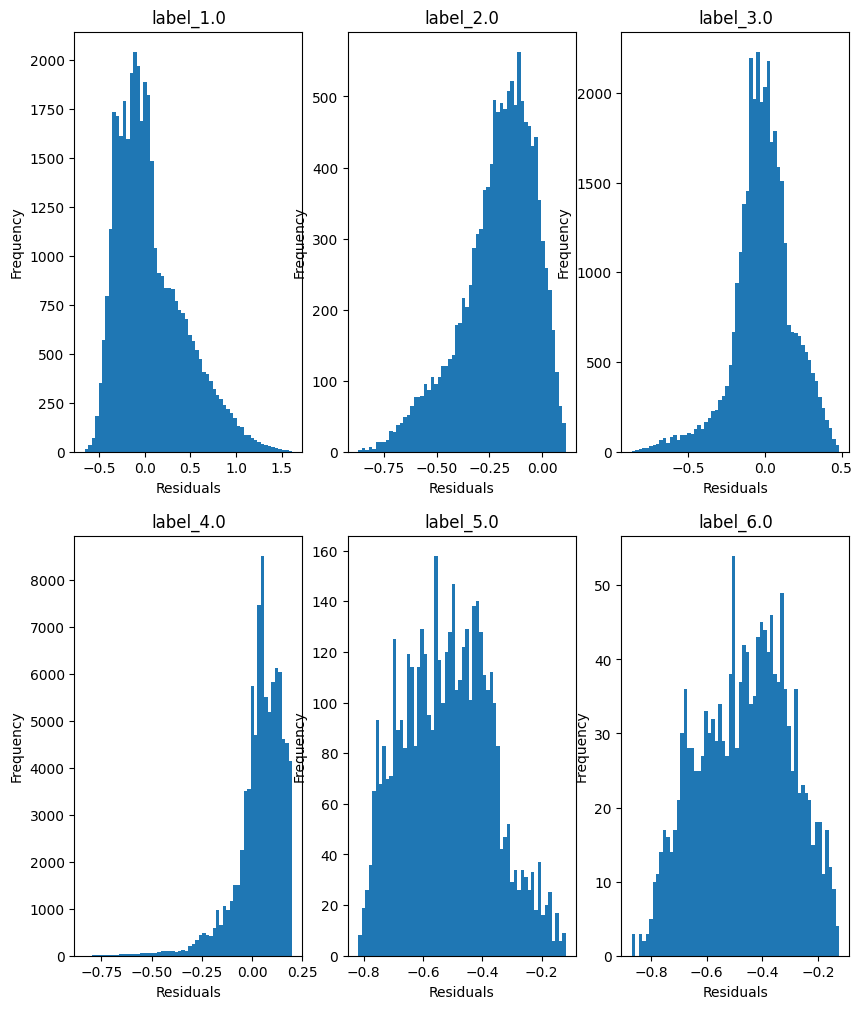

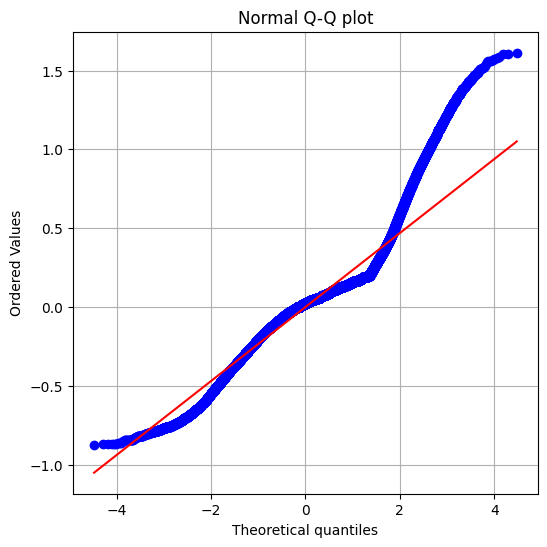

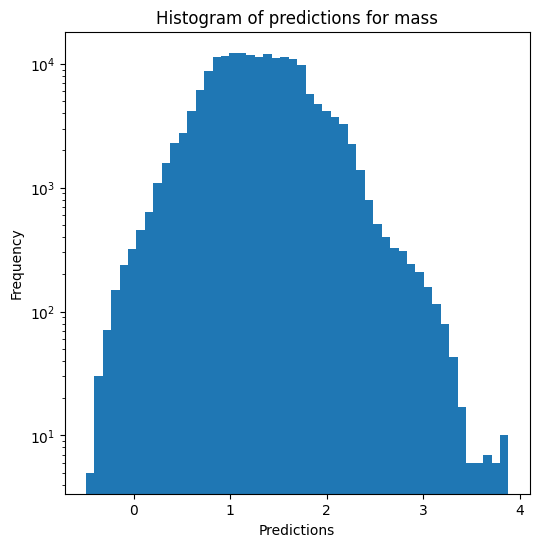

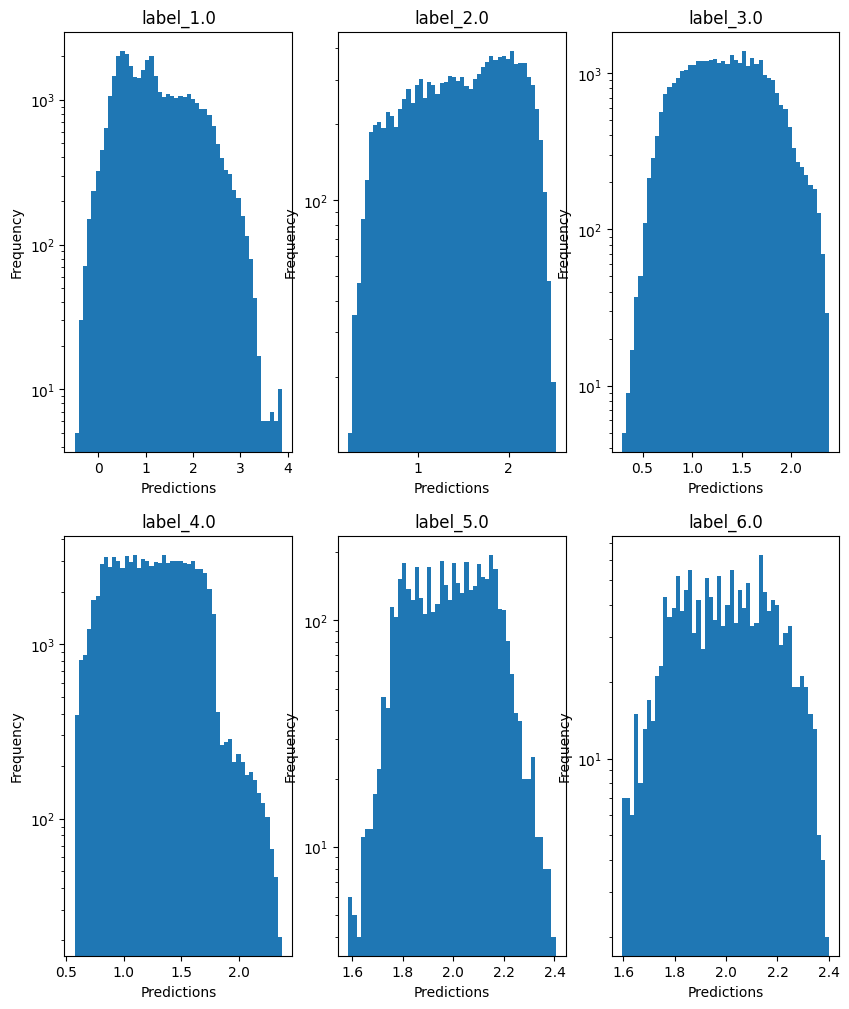

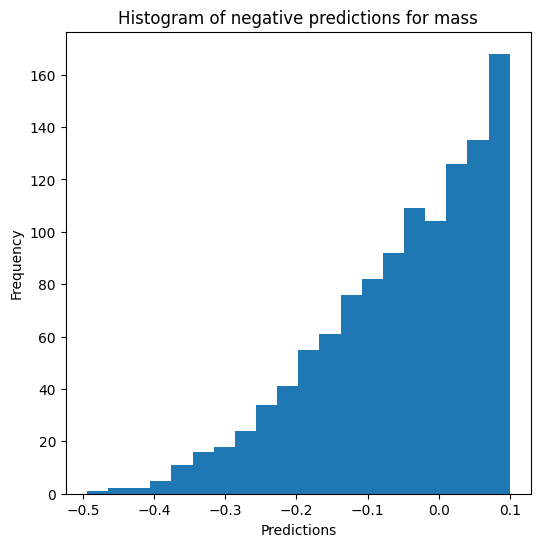


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9359057168106986
  RMSE :  0.07692690266935939
  MAE :  0.05907388999221467
  MedAE :  0.04887203778955569
  CORR :  0.968139437154013
  MAX_ER :  0.3049602043335925
  Percentiles : 
    75th percentile :  0.076560756412478
    90th percentile :  0.12336082624051967
    95th percentile :  0.1672821511200591
    99th percentile :  0.23773761371742472

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9848676500607553
  RMSE :  0.04248635880308873
  MAE :  0.03614954928043464
  MedAE :  0.03504872909037304
  CORR :  0.9929563927643905
  MAX_ER :  0.09272064794561395
  Percentiles : 
    75th percentile :  0.05266804229223812
    90th percentile :  0.06823338340427704
    95th percentile :  0.07548236018028977
    99th percentile :  0.08405696584666558

radius results for the label catego

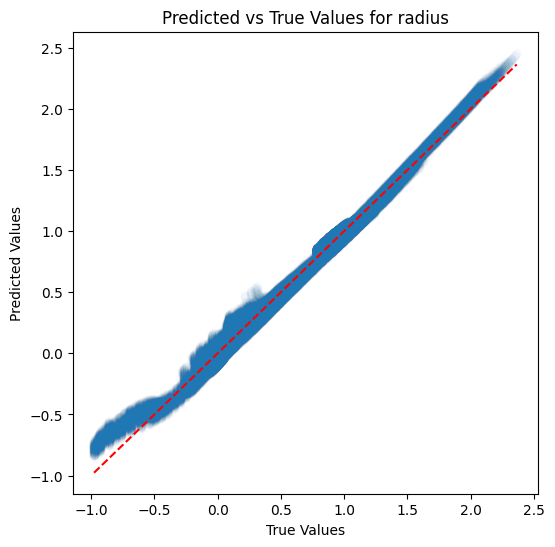

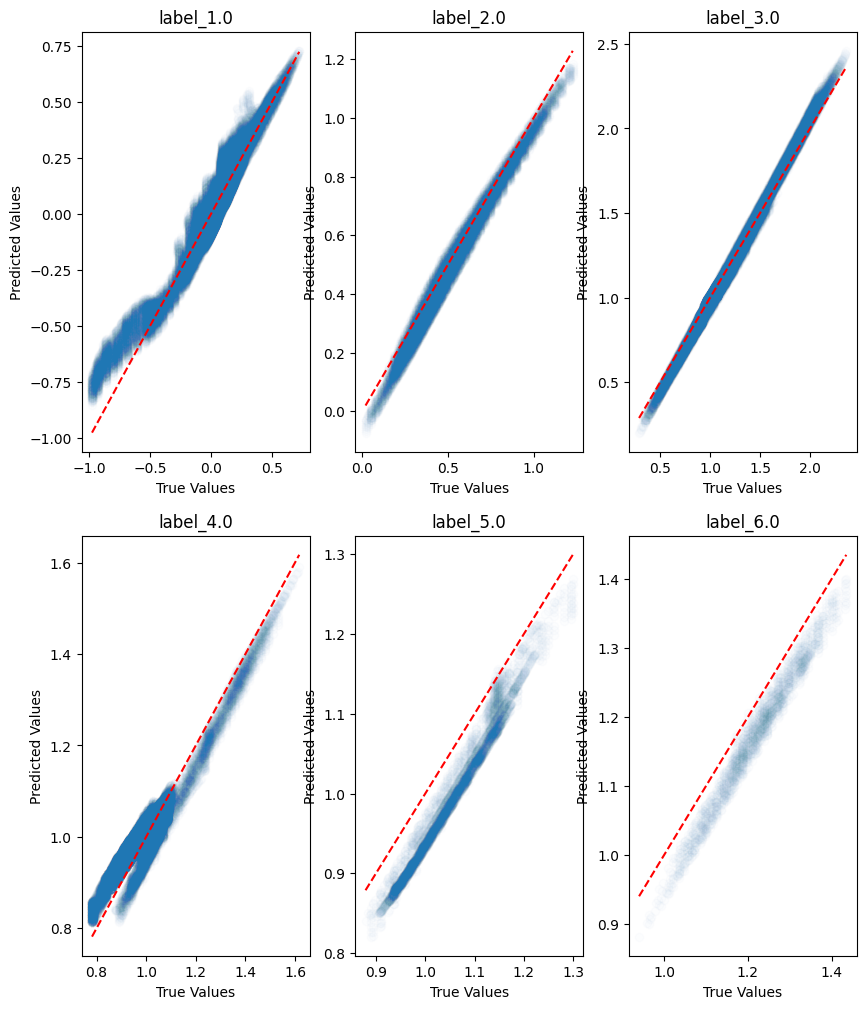

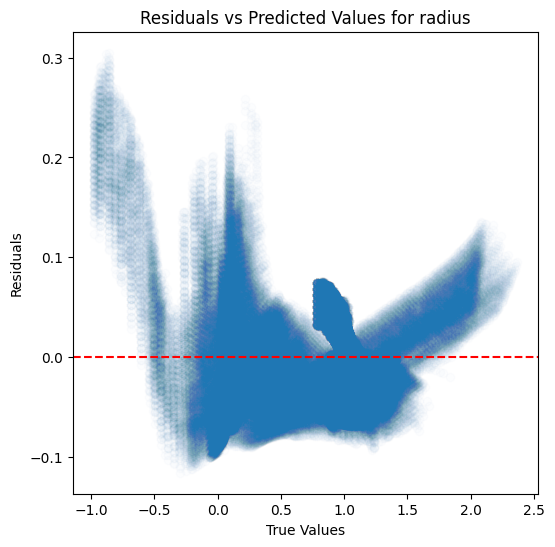

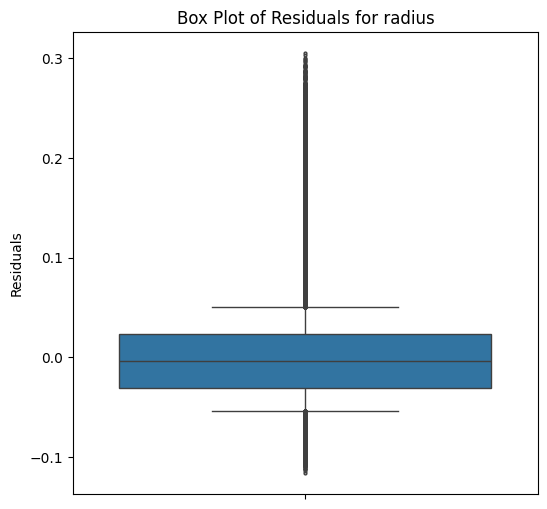

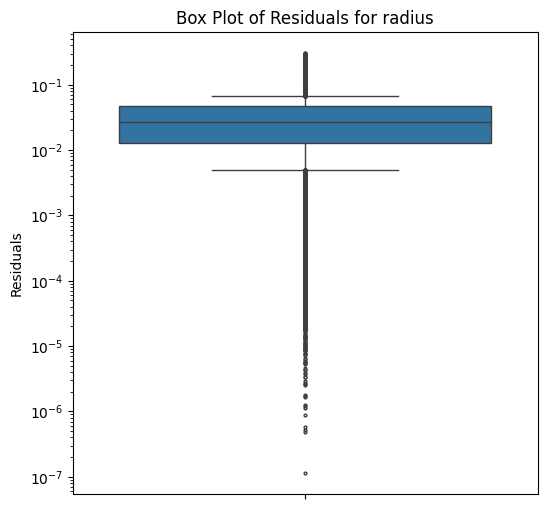

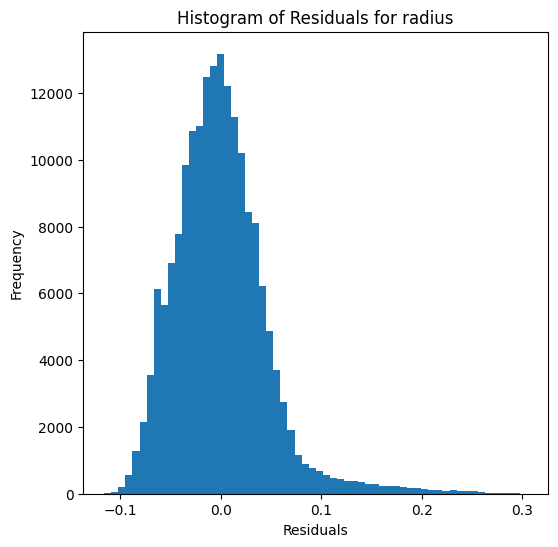

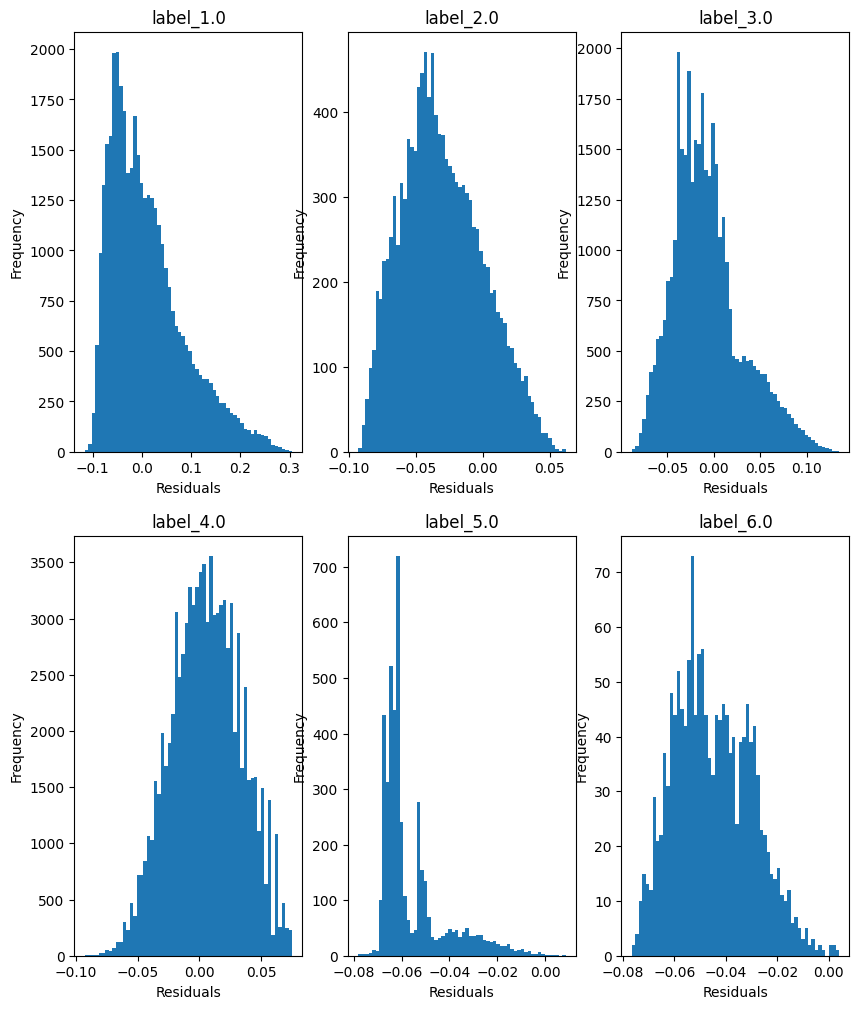

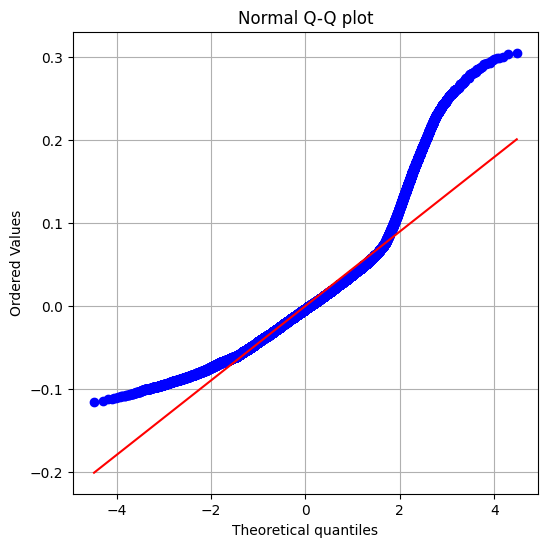

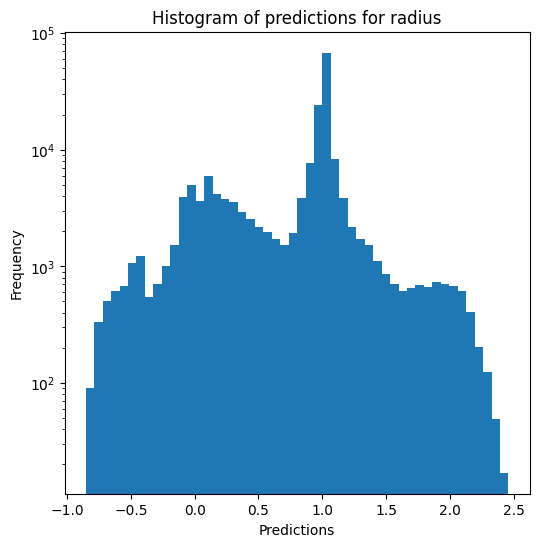

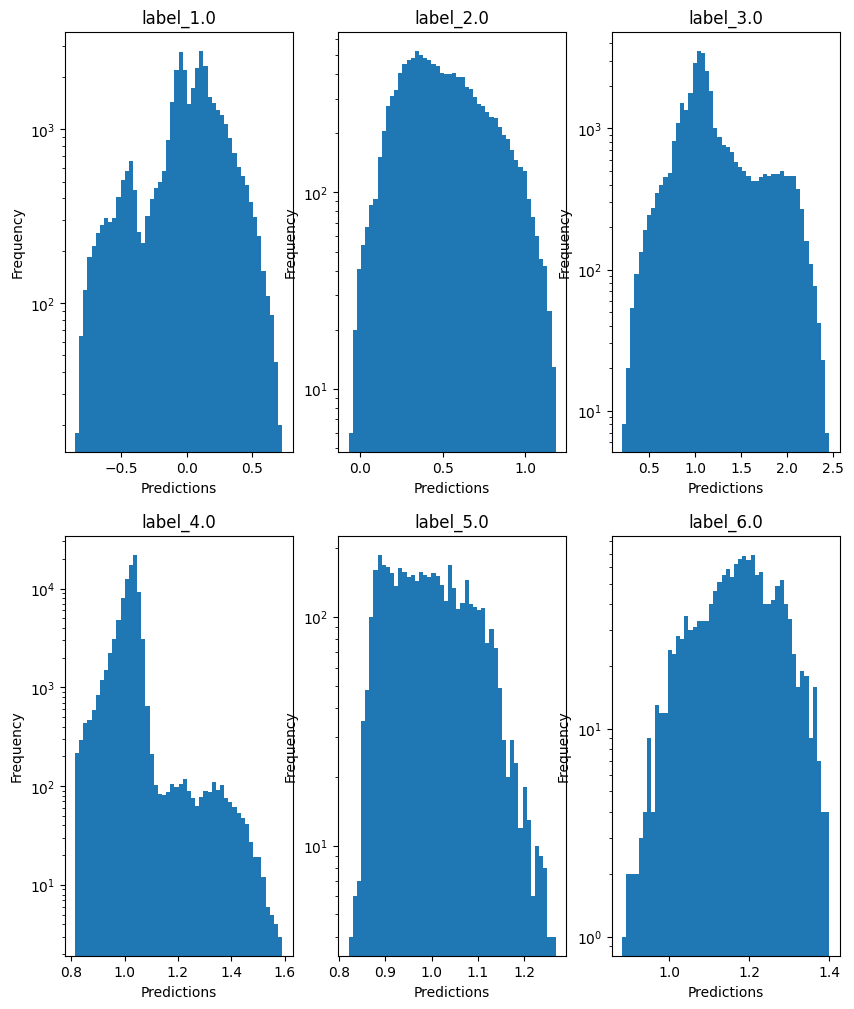

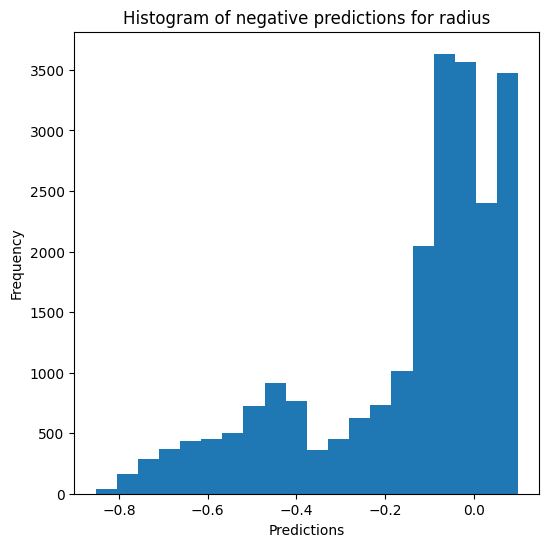

Saving predictions and results...


In [12]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True)

### Decision tree

In [13]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_stand_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9996093904727862
  RMSE :  0.01269243193794733
  MAE :  0.0035696795971781803
  MedAE :  0.0
  CORR :  0.9998047224742765
  MAX_ER :  0.3129999999999997
  Percentiles : 
    75th percentile :  0.0009999999999998899
    90th percentile :  0.010000000000000009
    95th percentile :  0.02100000000000002
    99th percentile :  0.05900000000000016

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.999736435649117
  RMSE :  0.010275626423851537
  MAE :  0.002843769968051136
  MedAE :  0.0
  CORR :  0.9998682388704653
  MAX_ER :  0.129
  Percentiles : 
    75th percentile :  4.440892098500626e-16
    90th percentile :  0.0050000000000000044
    95th percentile :  0.020000000000000018
    99th percentile :  0.04200000000000004

mass results for the label category with a value of 3.0
  value range :  0.655 - 2.999
  RVE :  0.9985882560728294
  RMSE : 

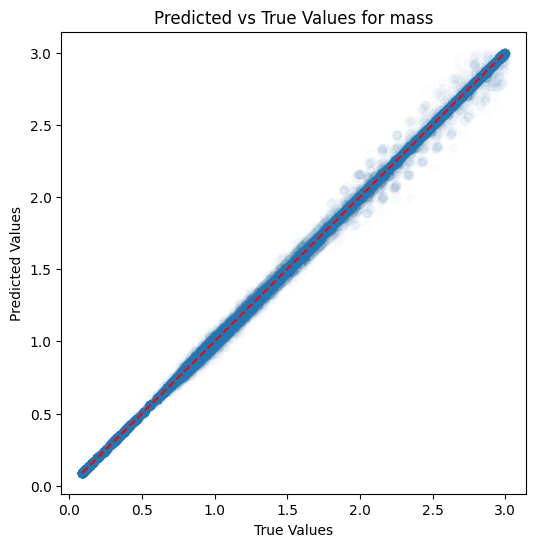

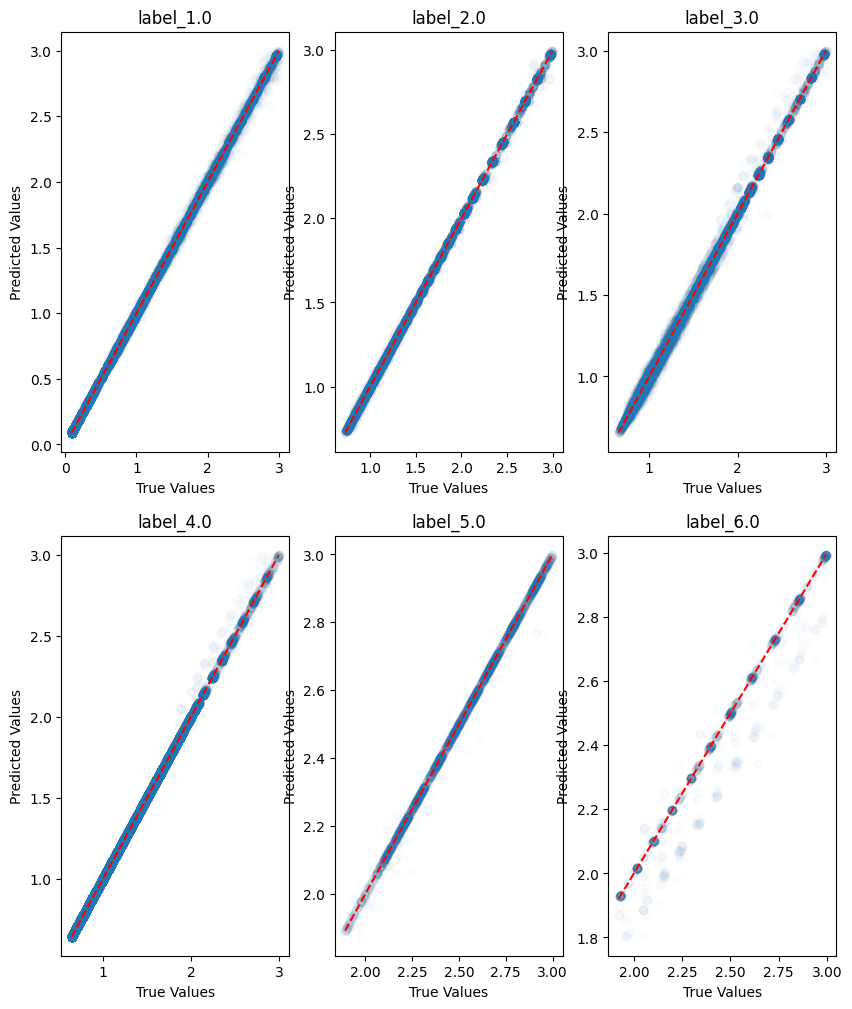

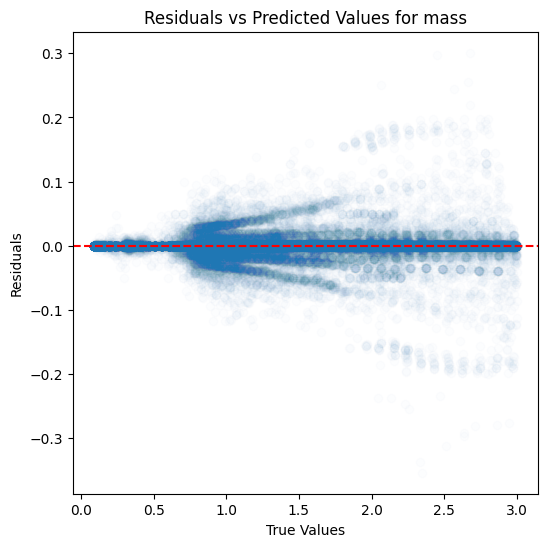

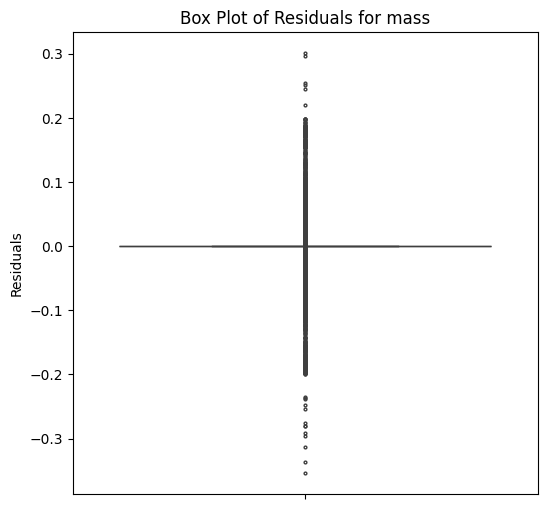

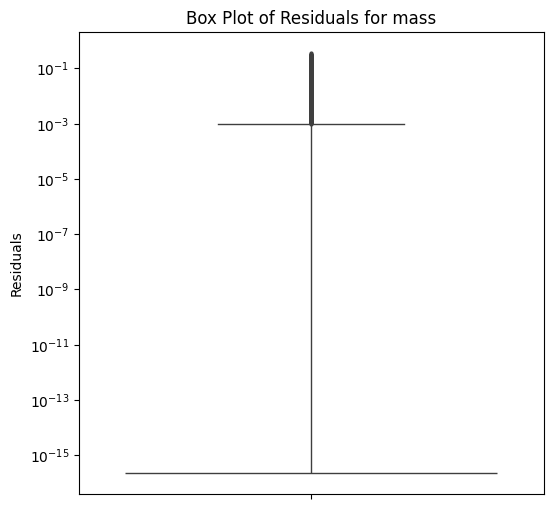

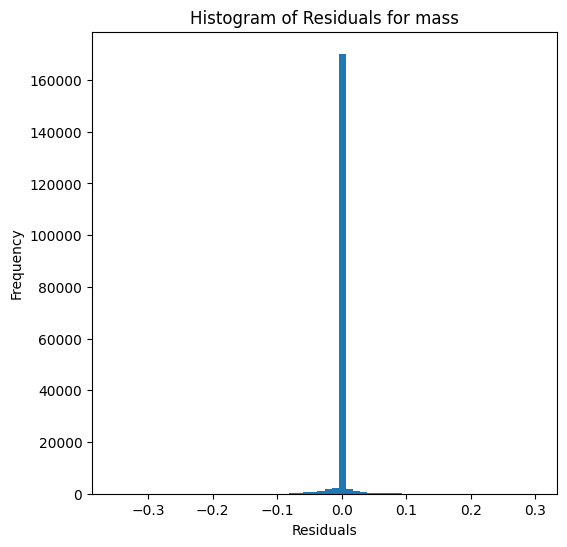

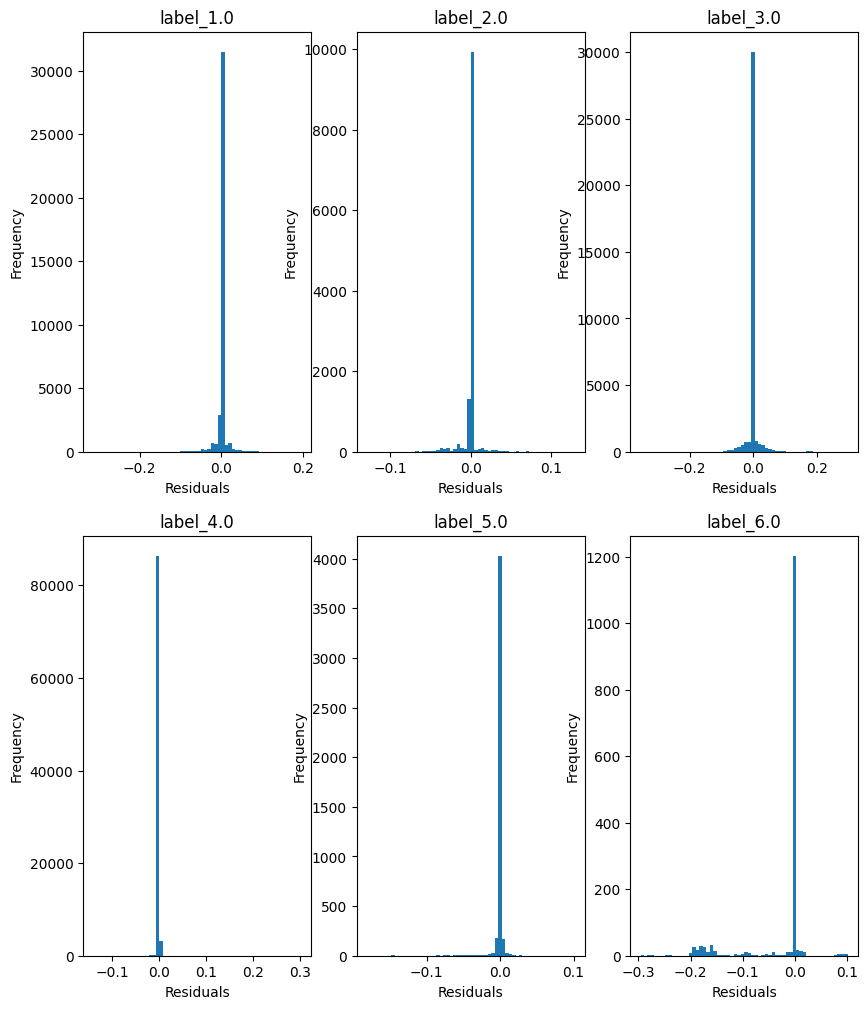

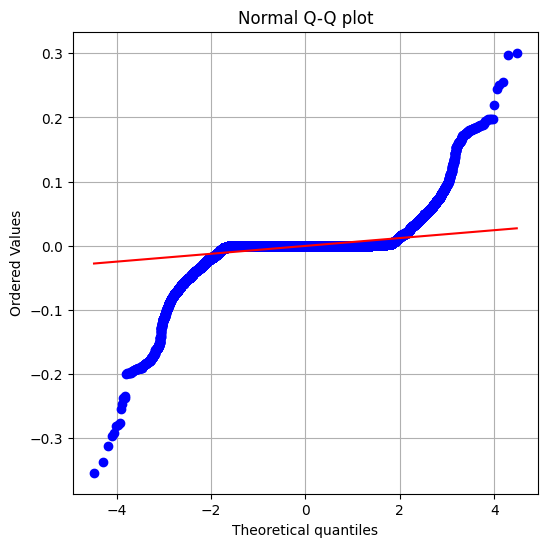

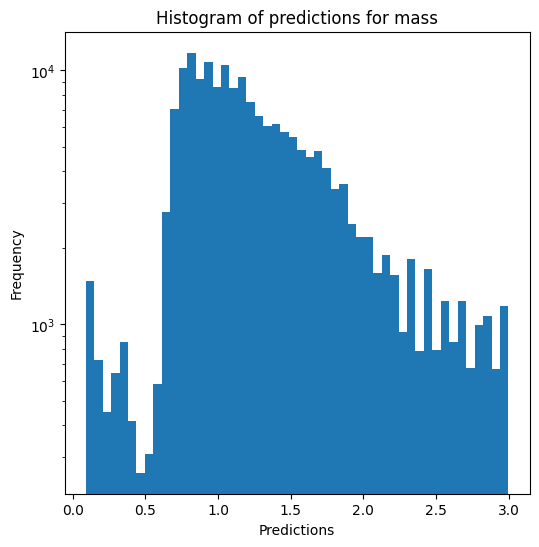

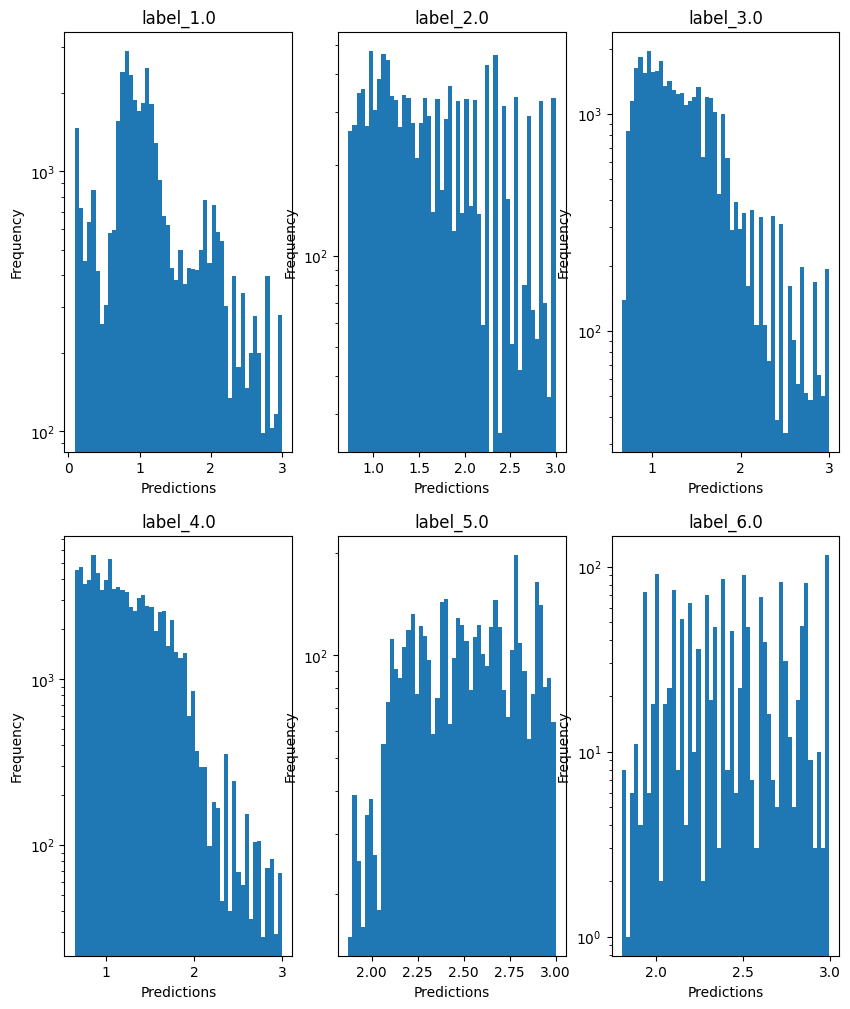

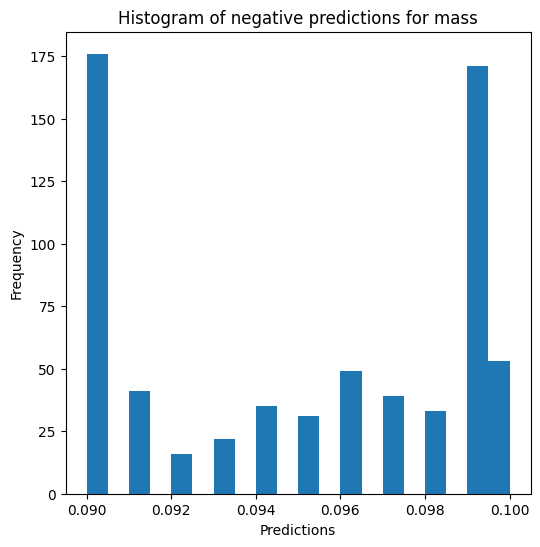

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9997324279678669
  RMSE :  0.00491470022647413
  MAE :  0.001781809936250684
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998662084639114
  MAX_ER :  0.09731821483168046
  Percentiles : 
    75th percentile :  0.001234449644086956
    90th percentile :  0.0053507183841012
    95th percentile :  0.009828519079559471
    99th percentile :  0.022662537149474513

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9991645617887354
  RMSE :  0.0070571228637753836
  MAE :  0.003108627795683041
  MedAE :  0.0
  CORR :  0.9995830247021514
  MAX_ER :  0.0914021384144007
  Percentiles : 
    75th percentile :  0.003469541277798624
    90th percentile :  0.011528188396605452
    95th percentile :  0.01564137600162402
    99th percentile :  0.02773756586959331

radius results for the label categor

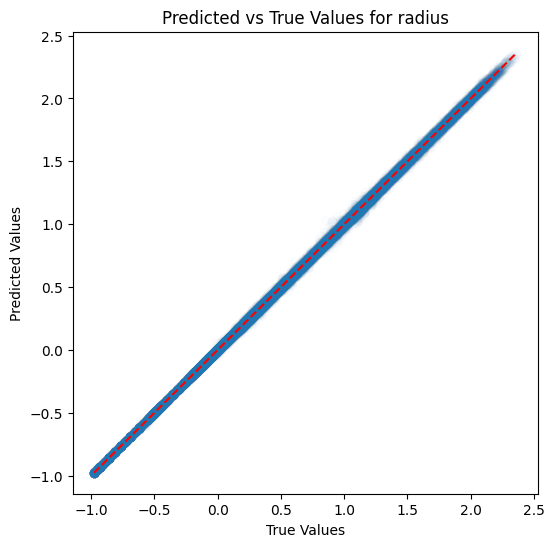

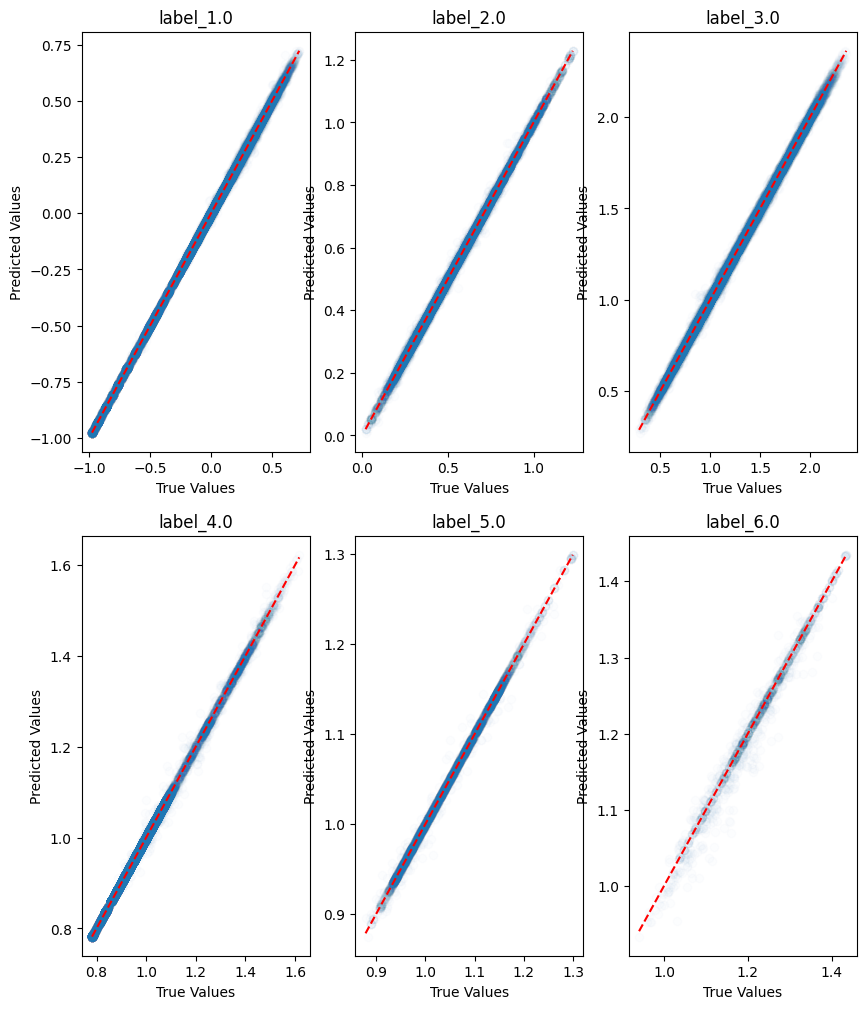

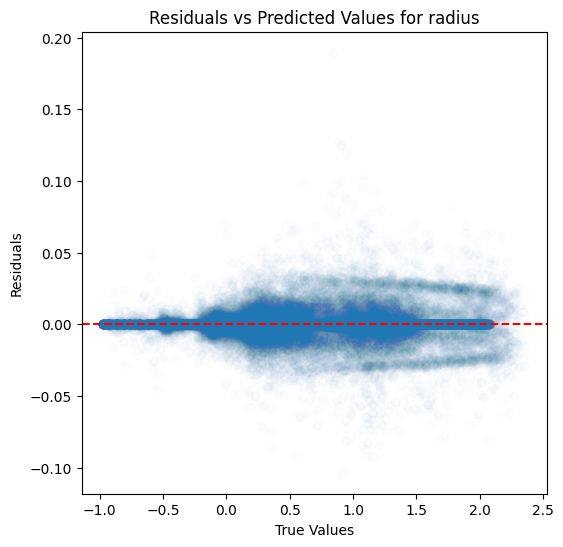

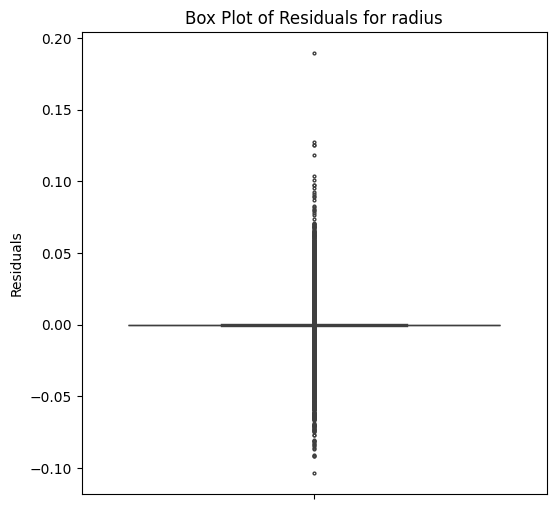

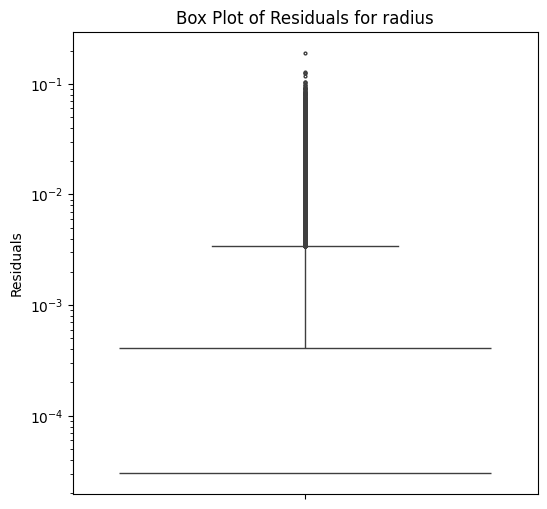

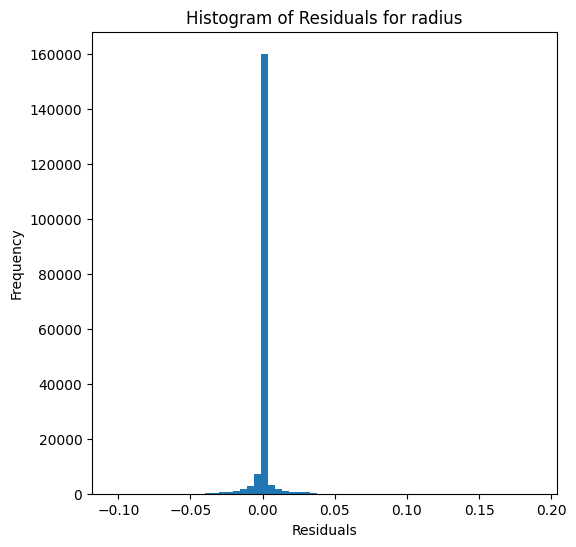

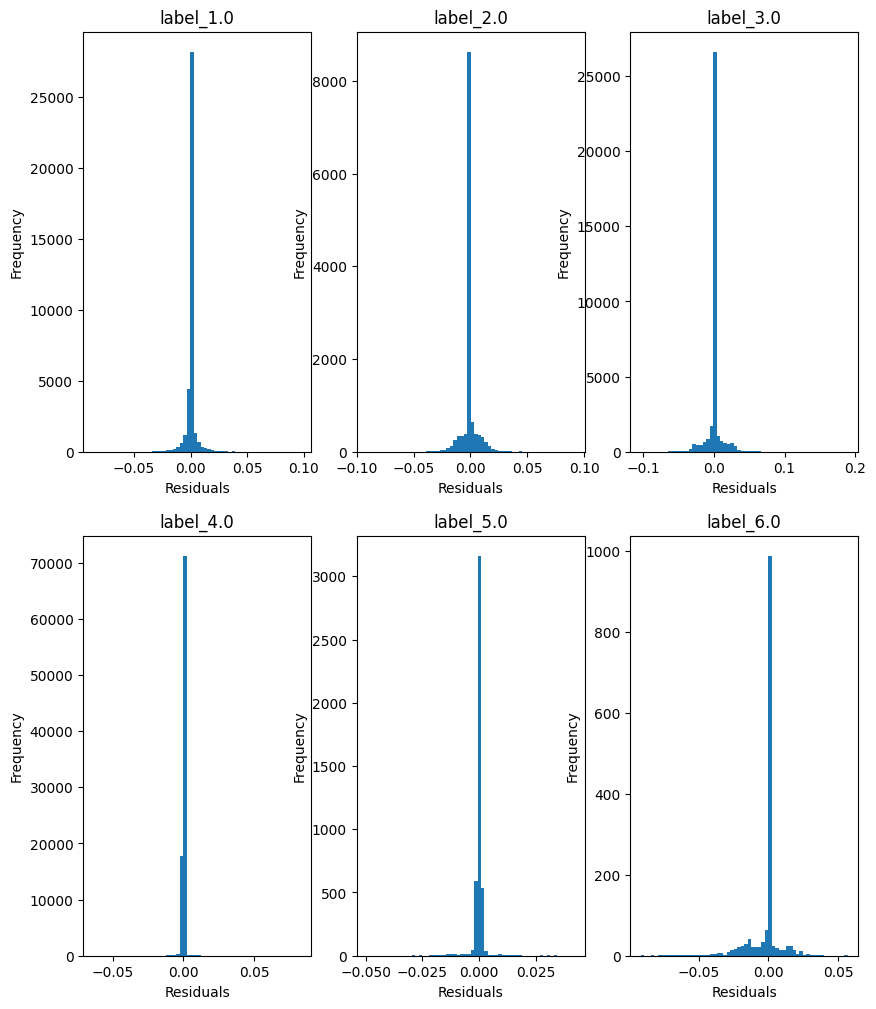

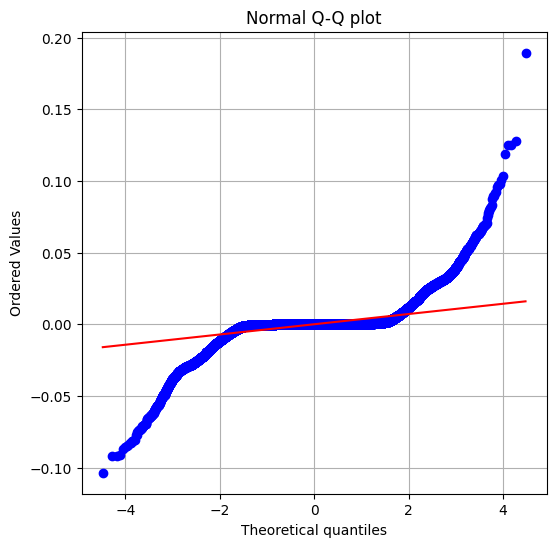

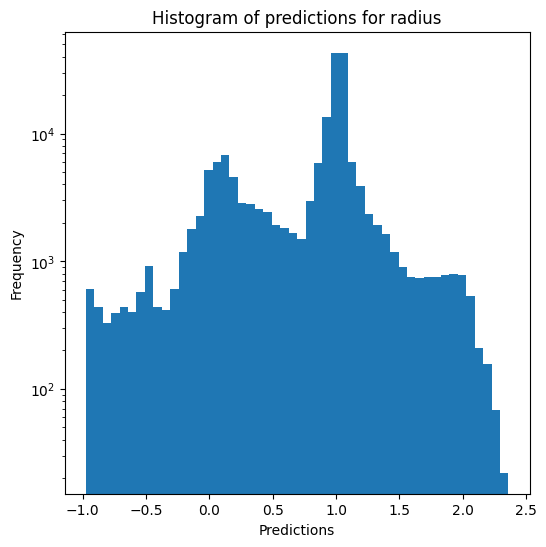

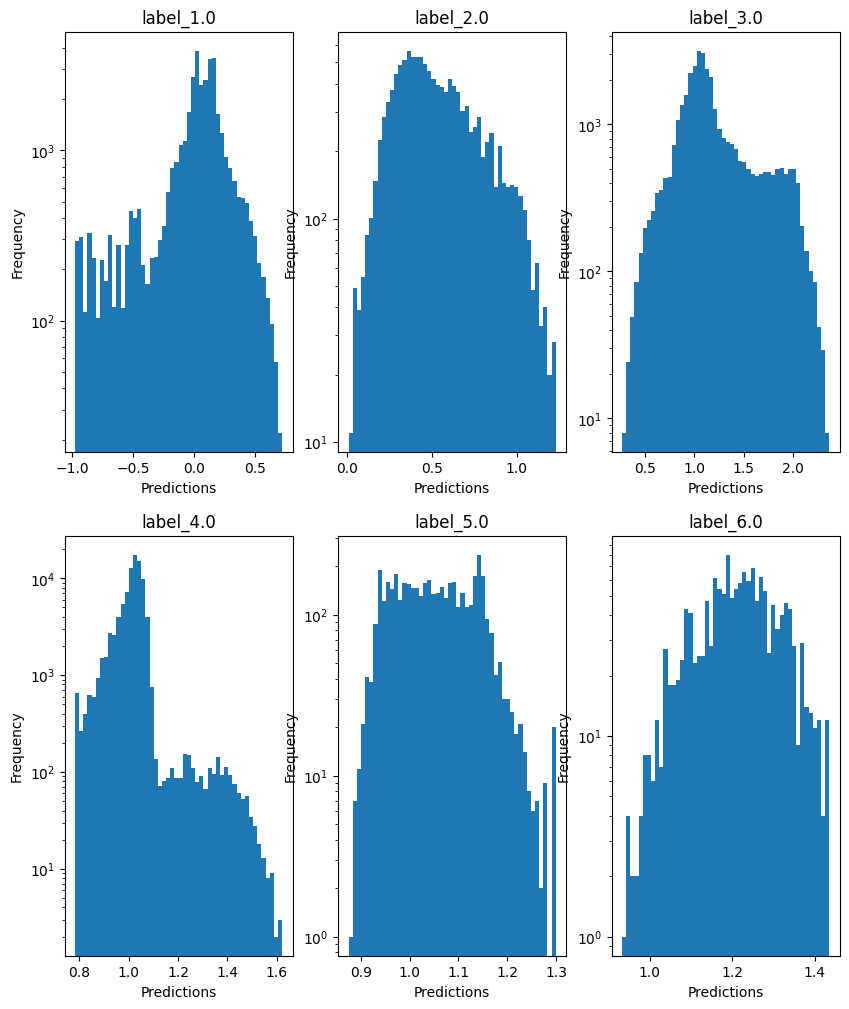

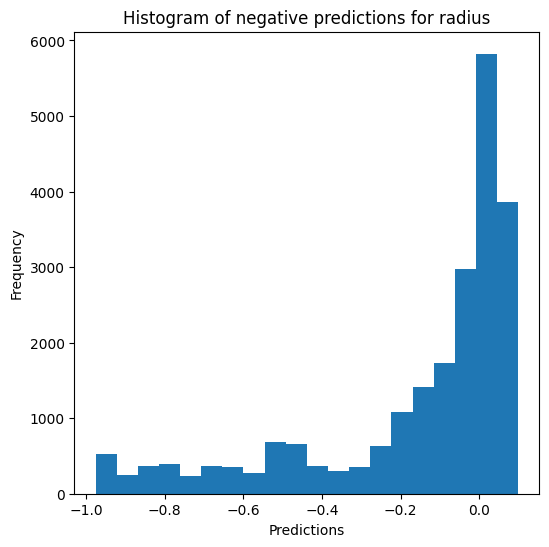

Saving predictions and results...


In [14]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True)

### K-nearest neighbours

In [15]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_stand_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9992200784353017
  RMSE :  0.017944237344957106
  MAE :  0.009590406115126623
  MedAE :  0.0040000000000000036
  CORR :  0.9996107857710236
  MAX_ER :  0.2088000000000001
  Percentiles : 
    75th percentile :  0.012199999999999989
    90th percentile :  0.02560000000000006
    95th percentile :  0.037800000000000056
    99th percentile :  0.07339999999999991

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9986005957680993
  RMSE :  0.02373536926179179
  MAE :  0.015203466453674123
  MedAE :  0.010599999999999943
  CORR :  0.9993335370159288
  MAX_ER :  0.18320000000000025
  Percentiles : 
    75th percentile :  0.02059999999999995
    90th percentile :  0.03400000000000025
    95th percentile :  0.049799999999999844
    99th percentile :  0.08576199999999987

mass results for the label category with a value of 3.0
  value range :  0.655 -

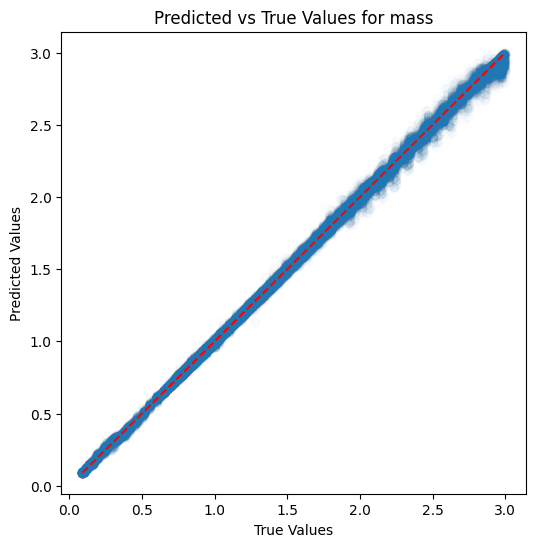

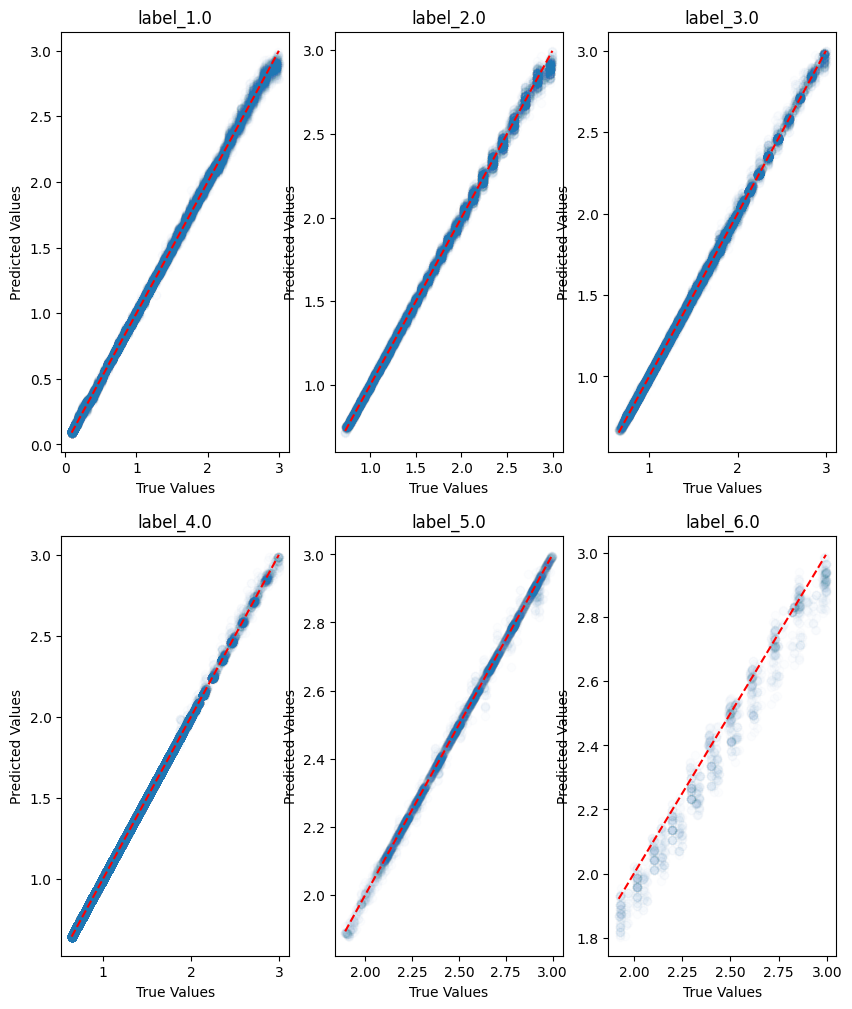

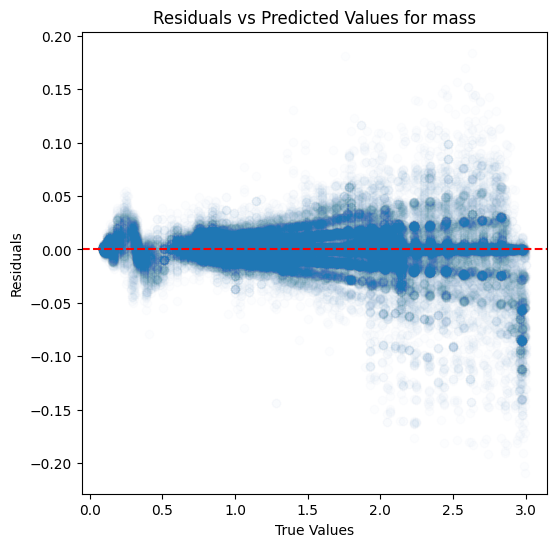

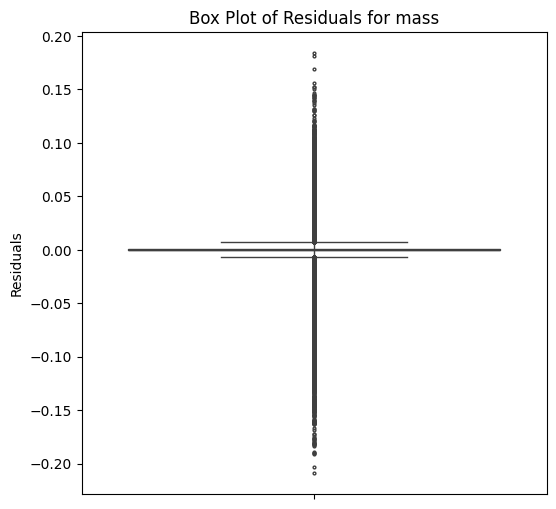

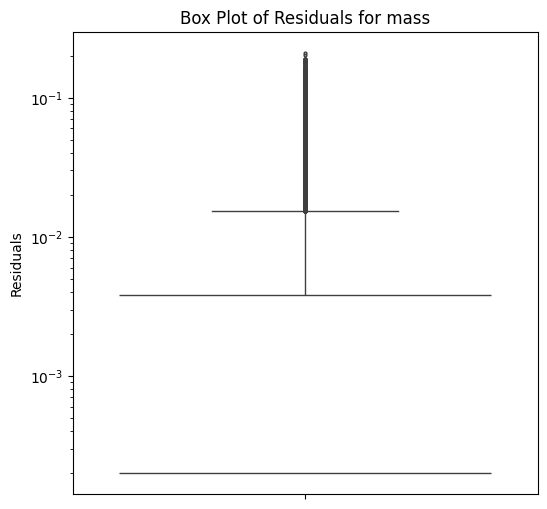

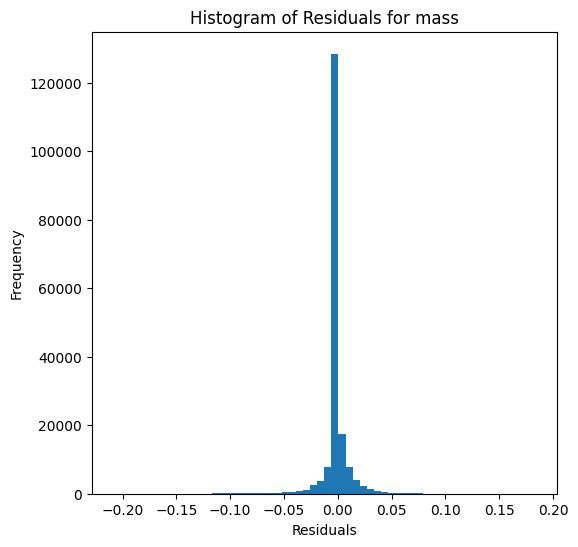

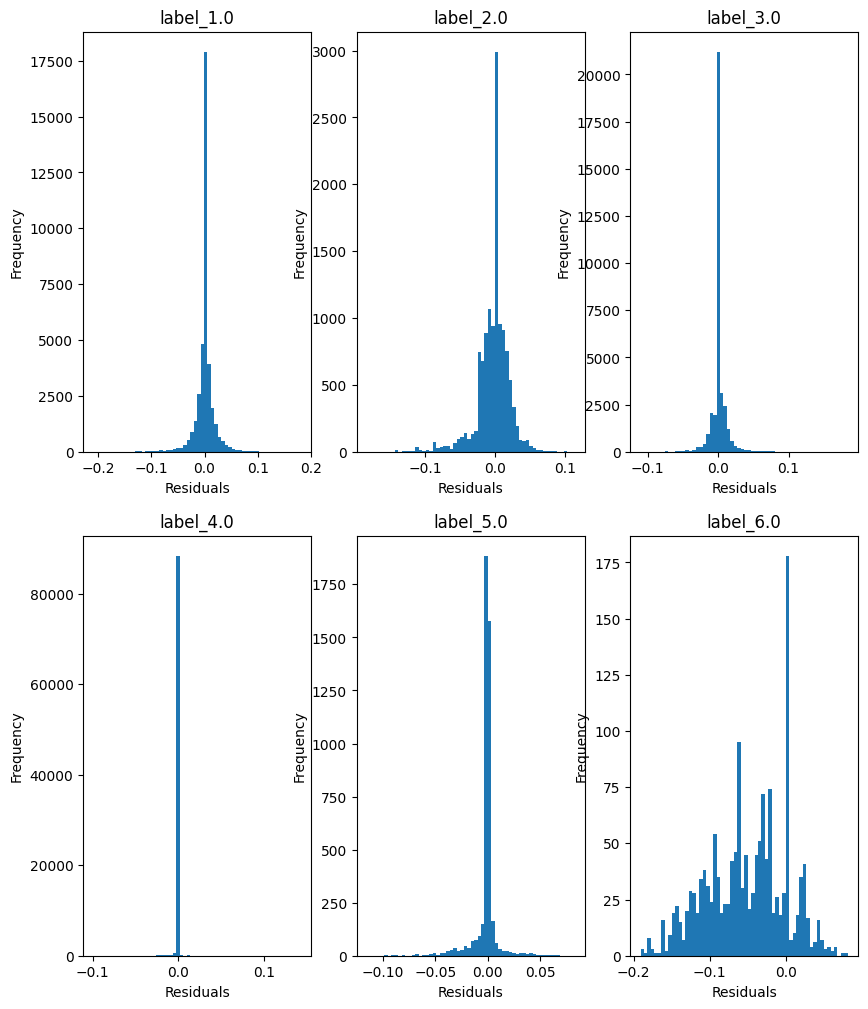

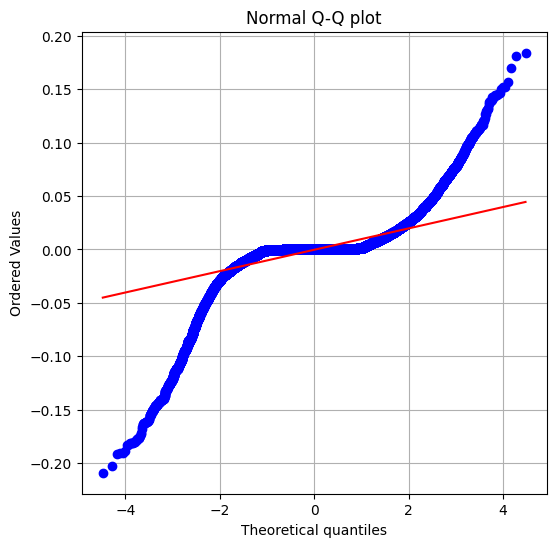

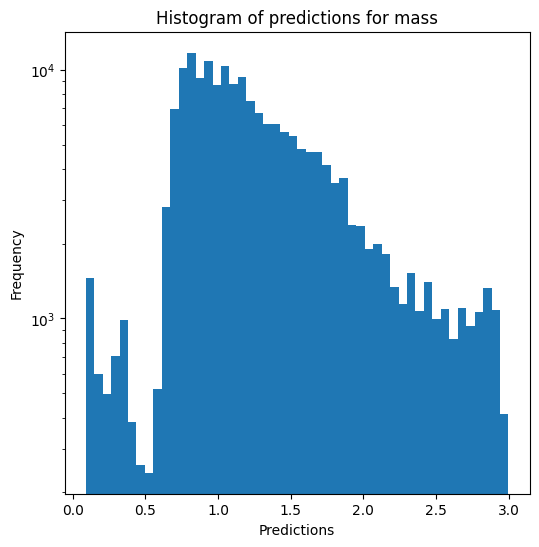

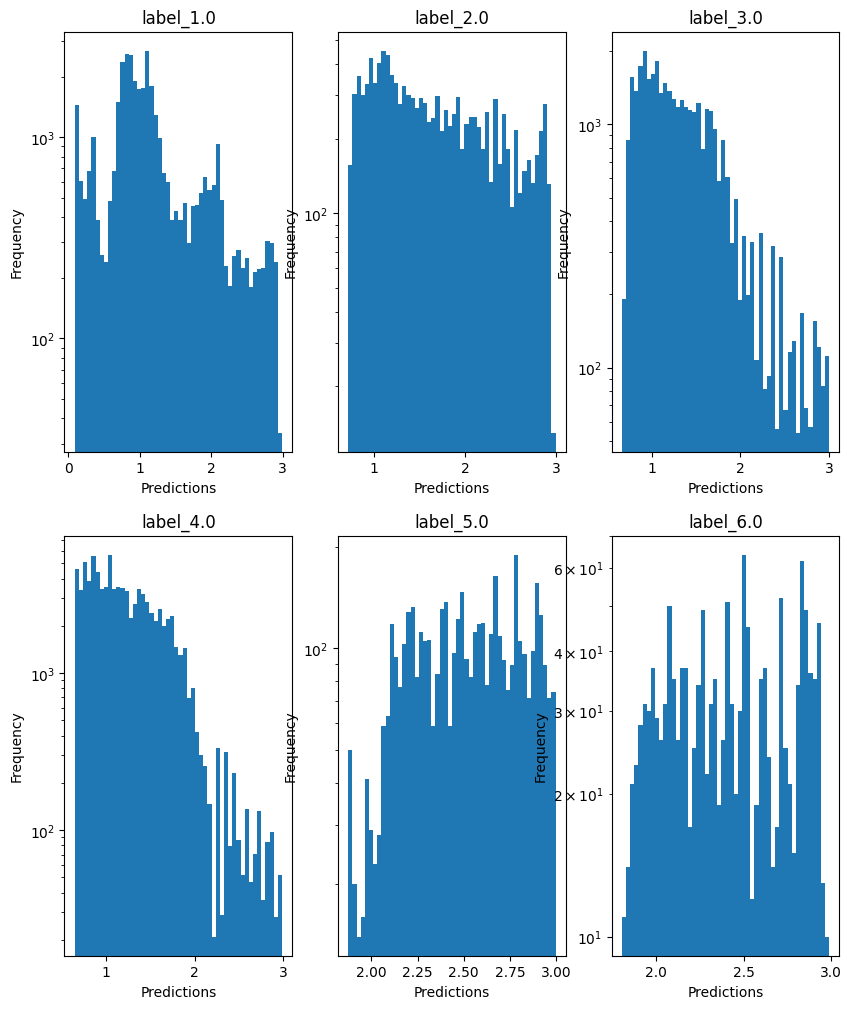

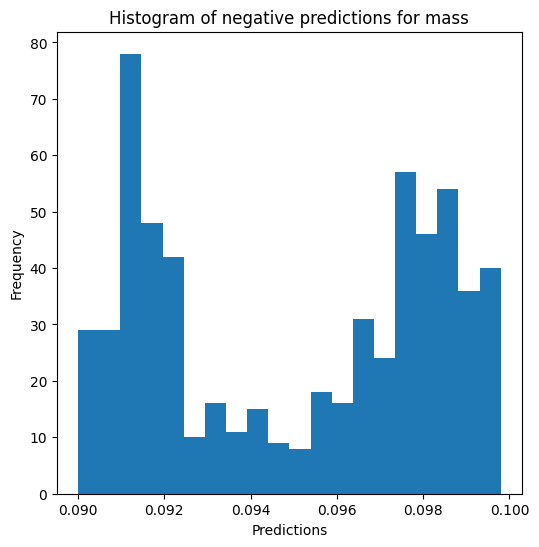


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9990643535169789
  RMSE :  0.00923512797289864
  MAE :  0.005534071261865851
  MedAE :  0.0026122170029375114
  CORR :  0.9995328025815527
  MAX_ER :  0.08818197587528859
  Percentiles : 
    75th percentile :  0.007668611600833656
    90th percentile :  0.015087581190891009
    95th percentile :  0.020839730955426922
    99th percentile :  0.033593110683916315

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9981899742313458
  RMSE :  0.01062466358216178
  MAE :  0.007906137853330152
  MedAE :  0.005967044692133938
  CORR :  0.9990954877497558
  MAX_ER :  0.05876396059309341
  Percentiles : 
    75th percentile :  0.01050742486856393
    90th percentile :  0.017023378271409786
    95th percentile :  0.022081913837288688
    99th percentile :  0.032977115701836666

radius results for

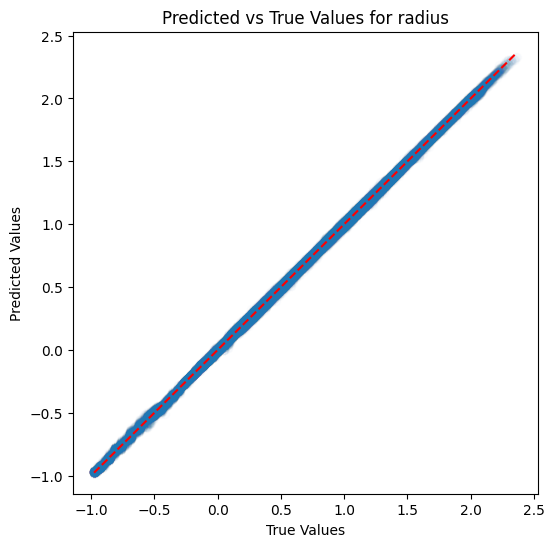

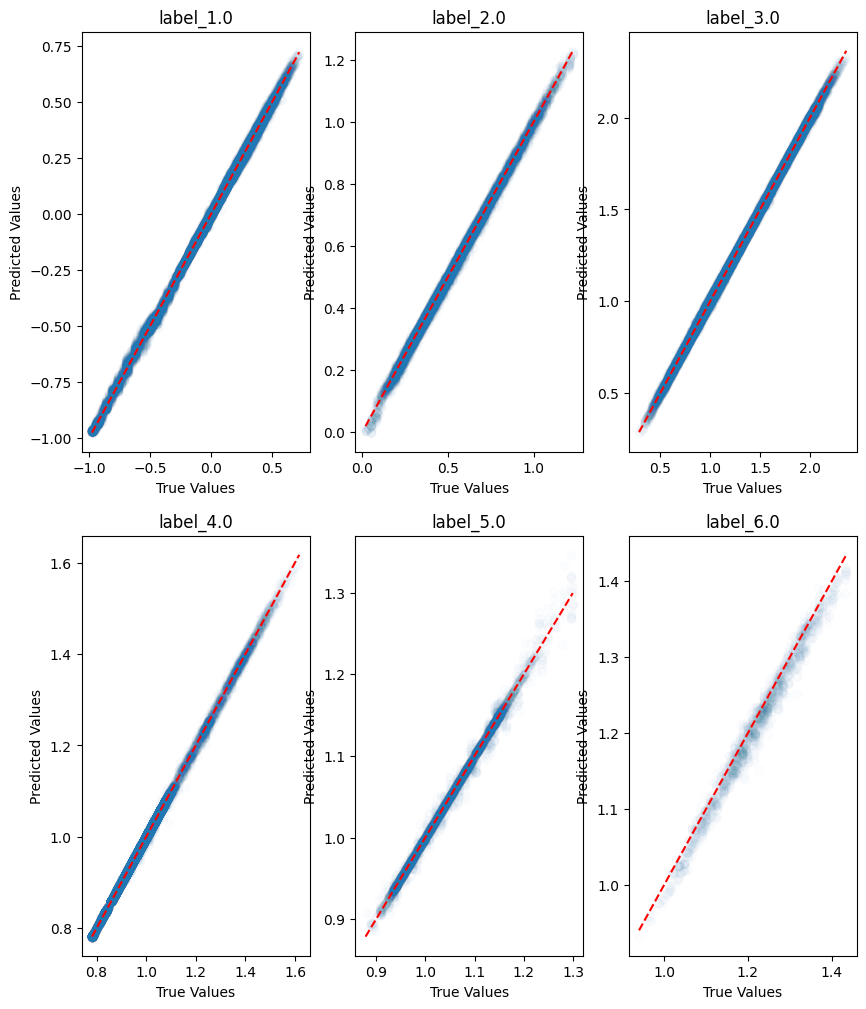

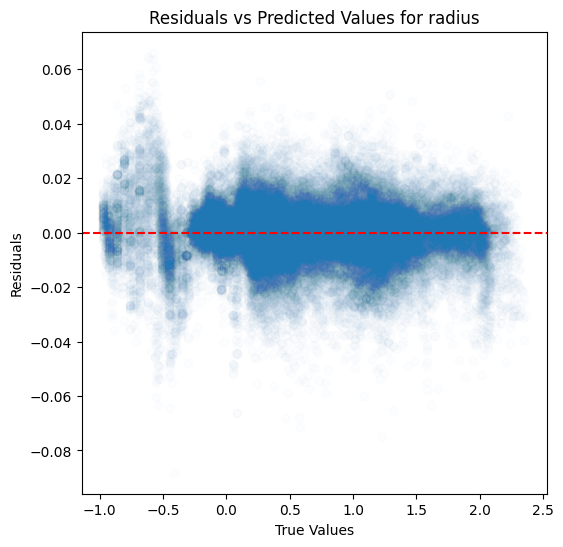

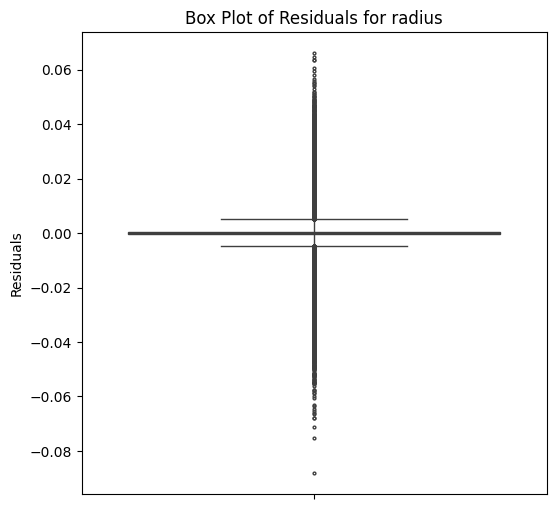

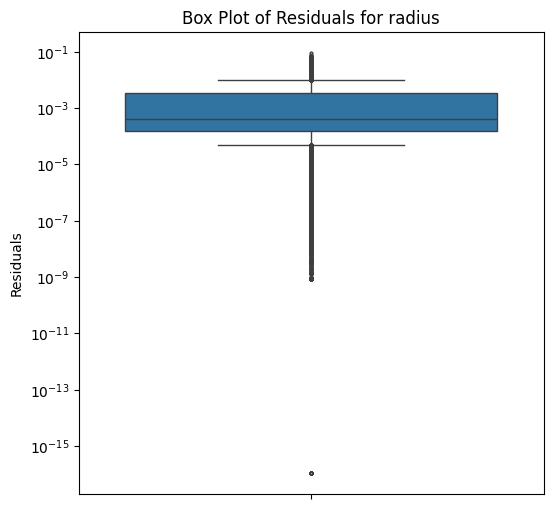

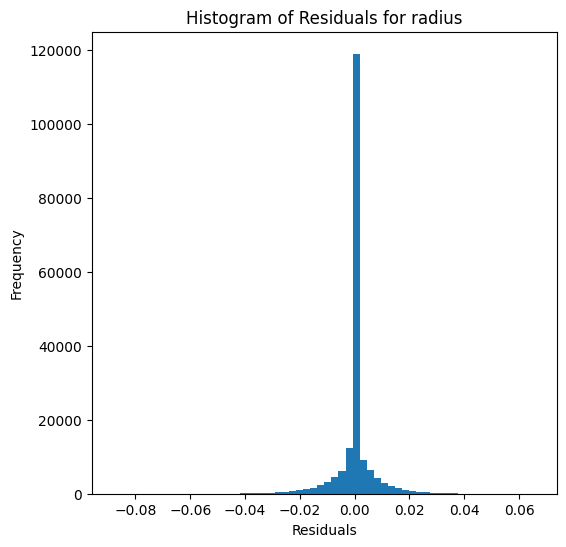

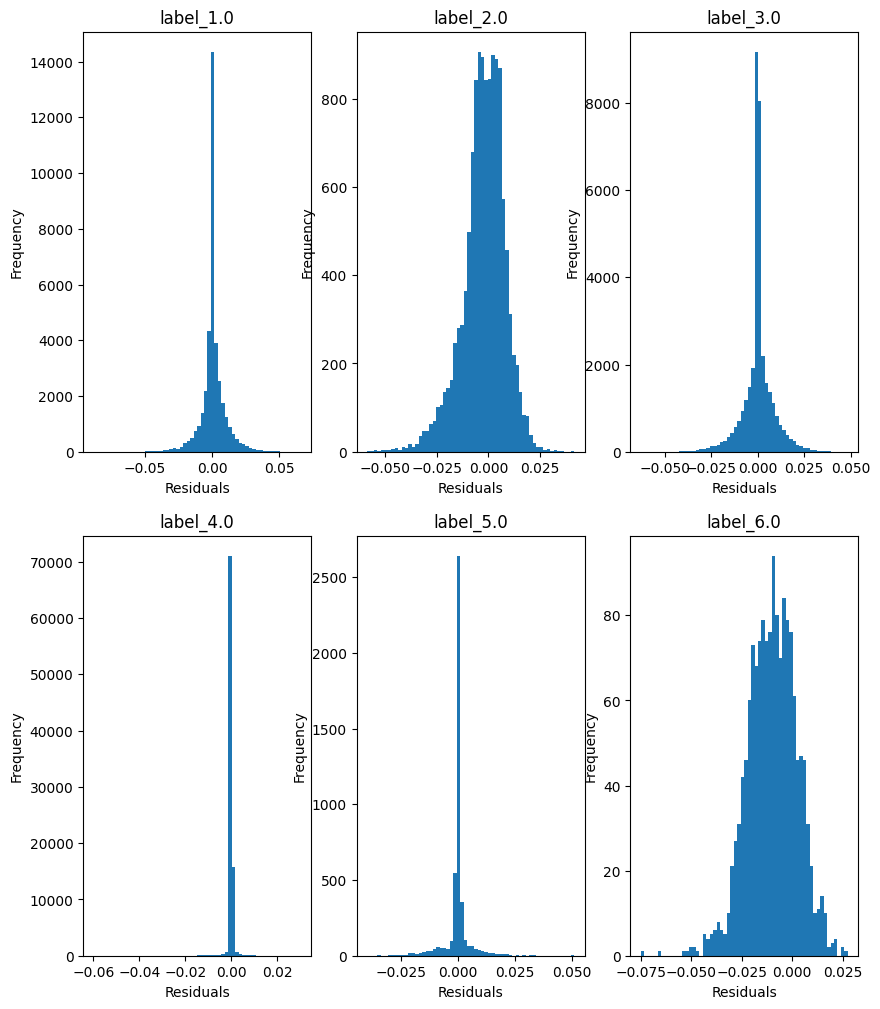

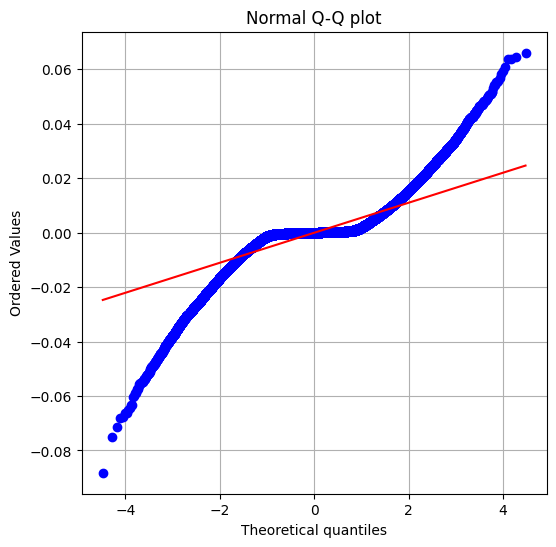

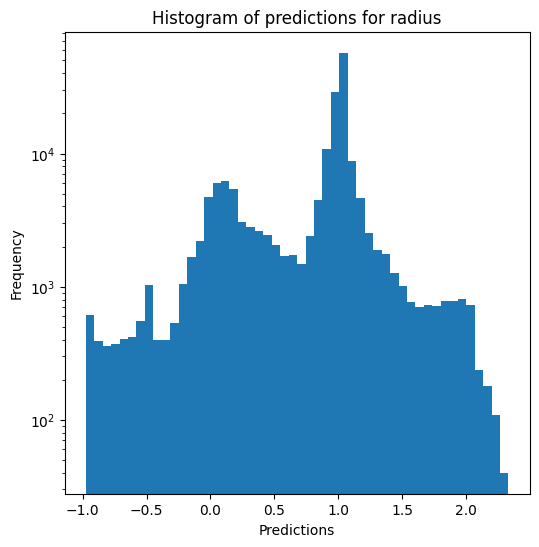

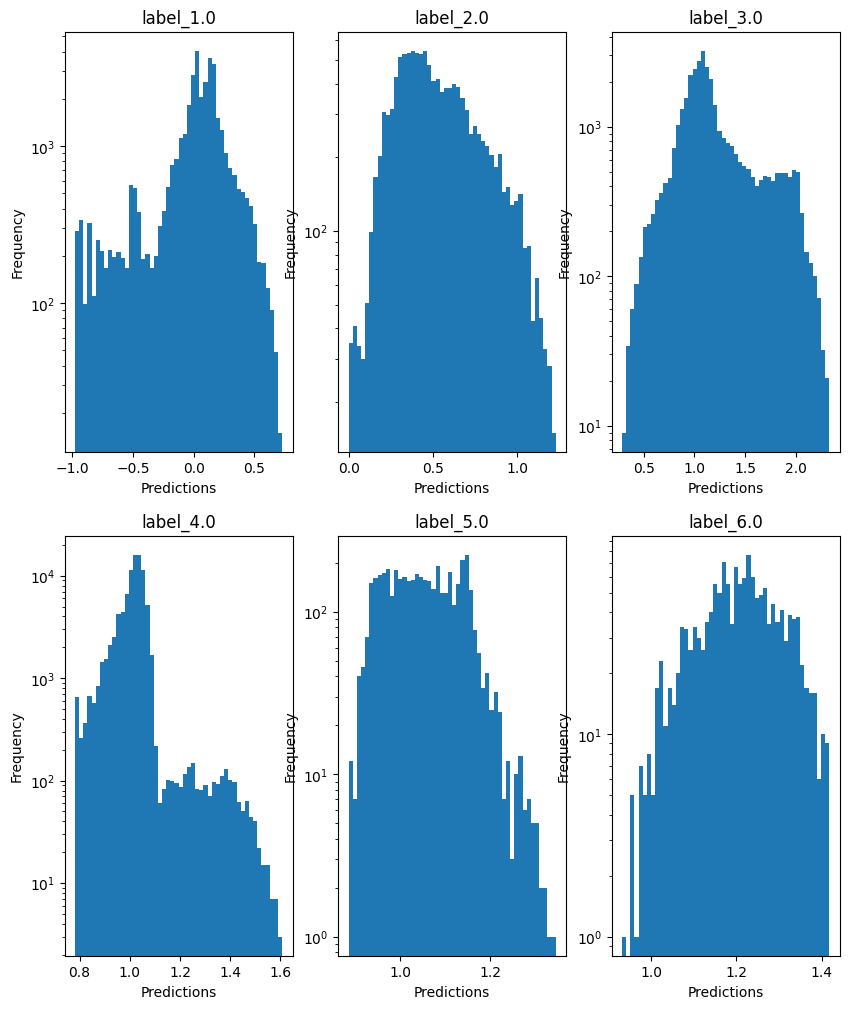

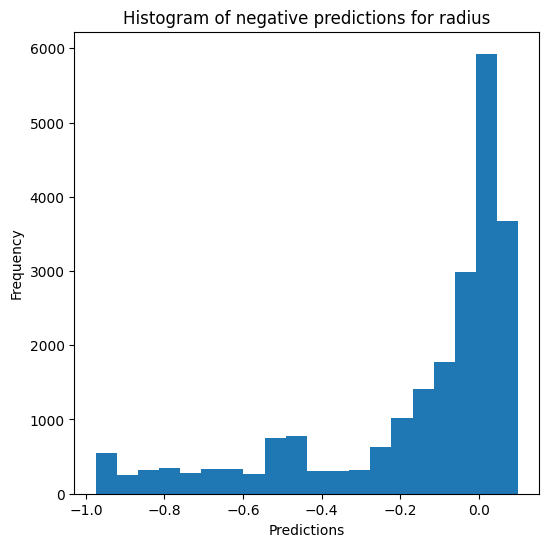

Saving predictions and results...


In [16]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [17]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_stand_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9998735102188937
  RMSE :  0.007227185845612343
  MAE :  0.0023474154699703324
  MedAE :  0.00013000000000018552
  CORR :  0.9999370538607467
  MAX_ER :  0.14463000000000026
  Percentiles : 
    75th percentile :  0.0011999999999998678
    90th percentile :  0.006570000000000509
    95th percentile :  0.012730000000001962
    99th percentile :  0.032733899999998095

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9998672264080737
  RMSE :  0.007352392605335931
  MAE :  0.003126538391906853
  MedAE :  0.00025999999999987145
  CORR :  0.9999338708296394
  MAX_ER :  0.09202999999999939
  Percentiles : 
    75th percentile :  0.0030299999999990612
    90th percentile :  0.010290000000001442
    95th percentile :  0.01658150000000147
    99th p

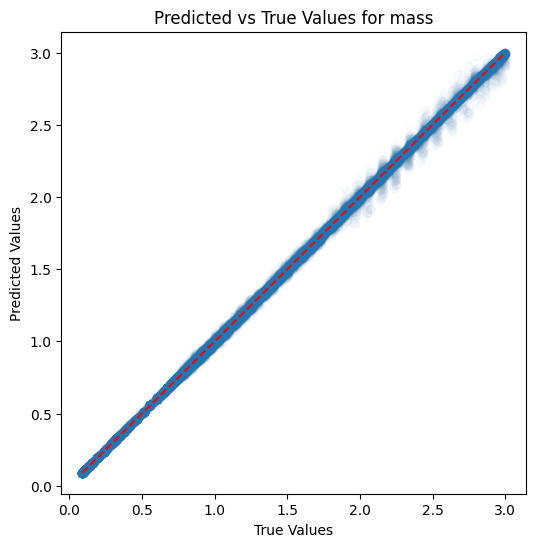

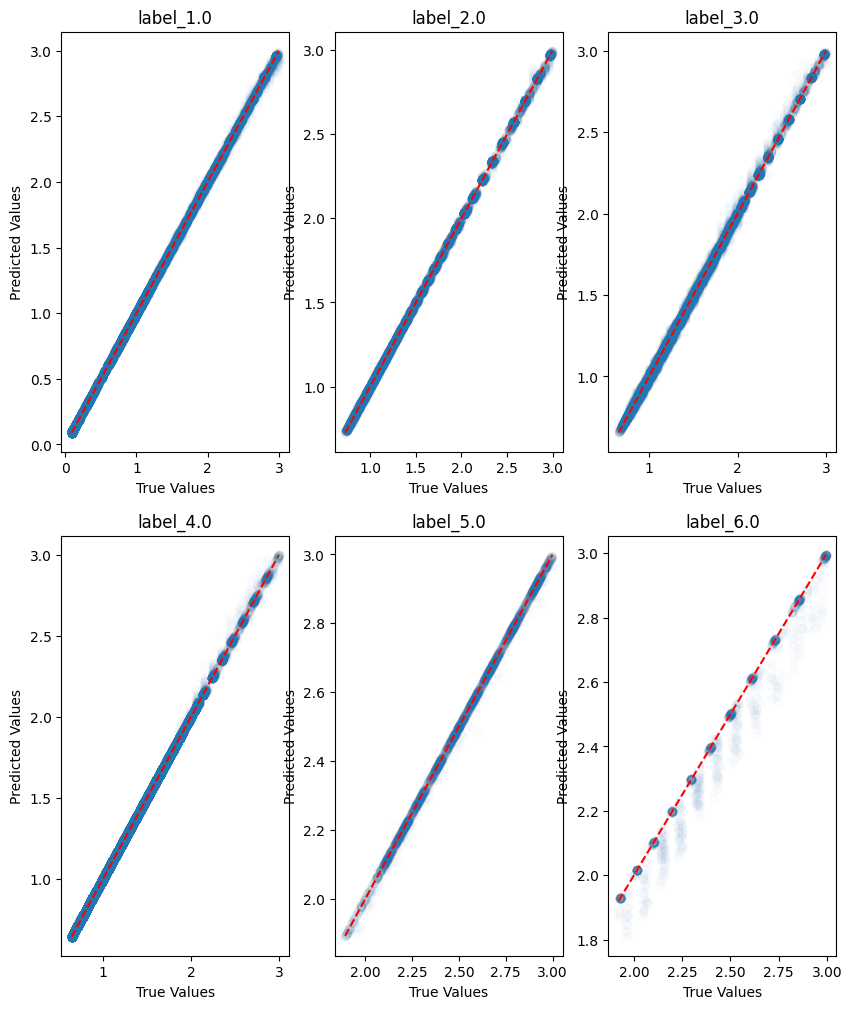

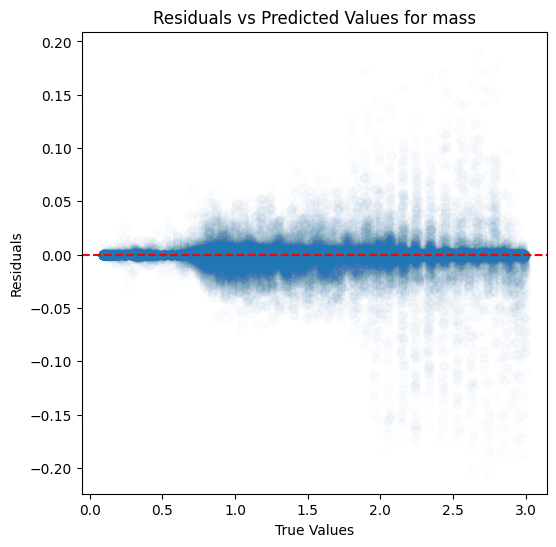

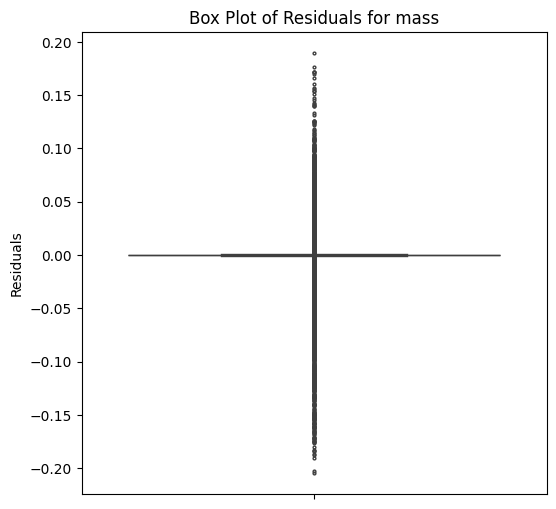

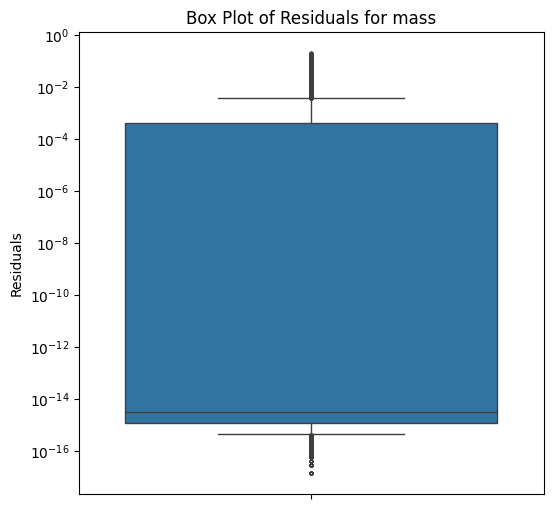

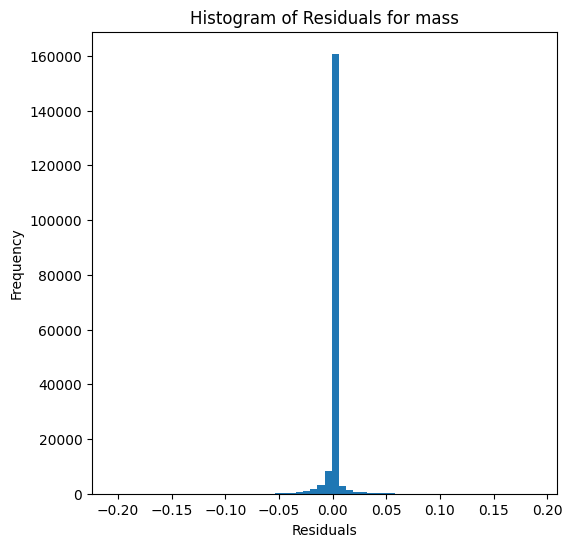

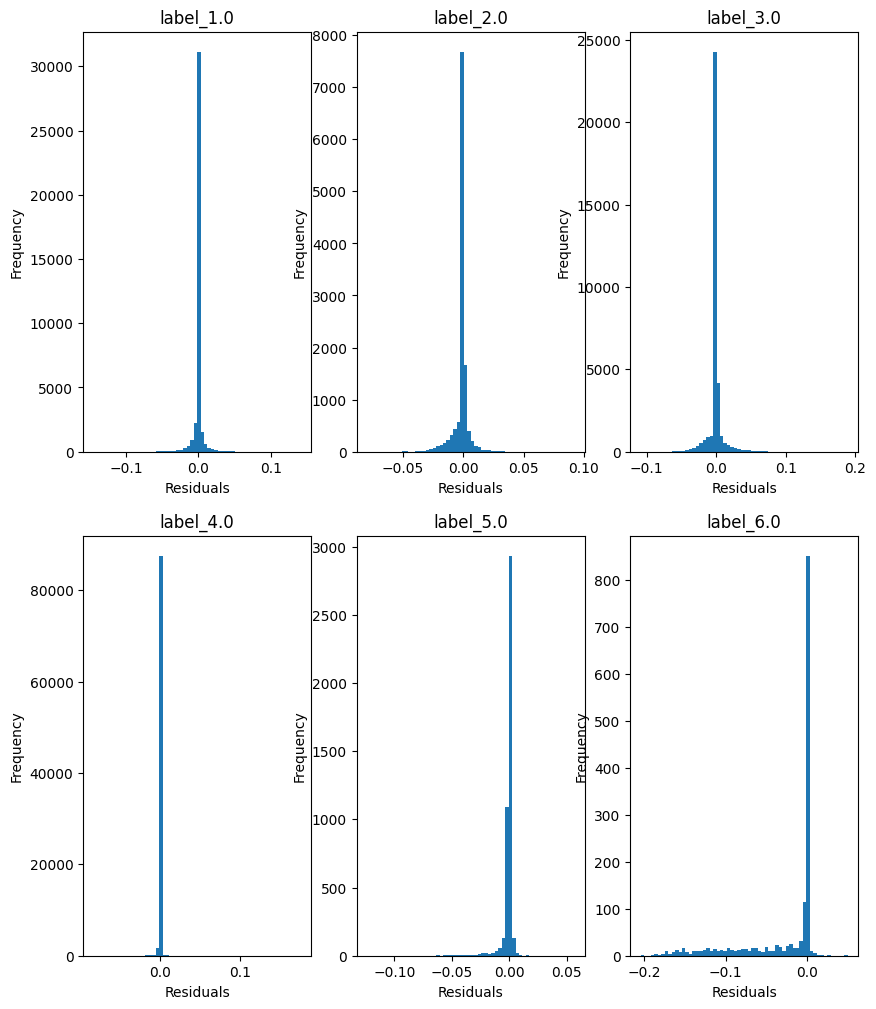

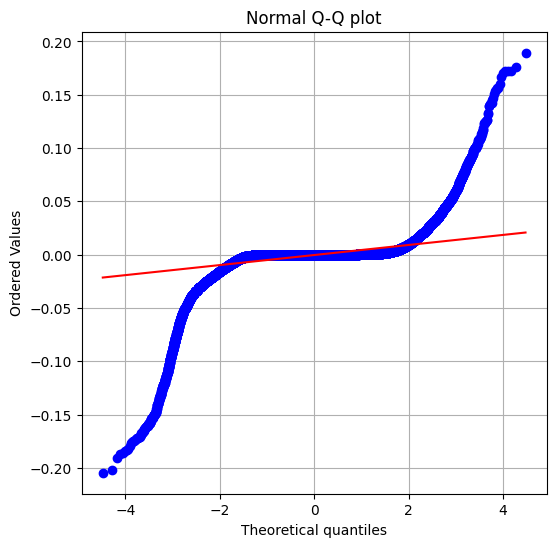

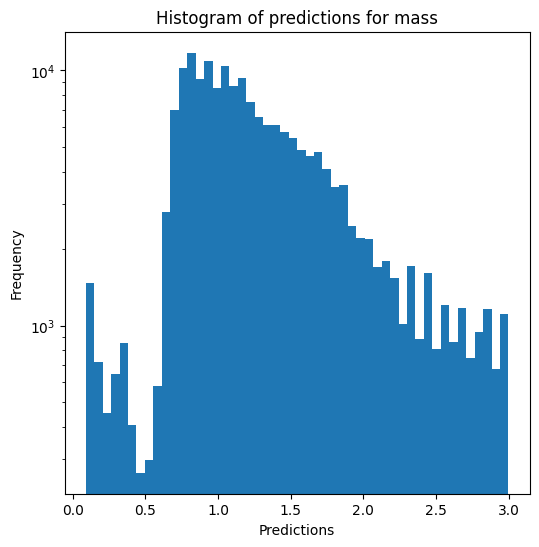

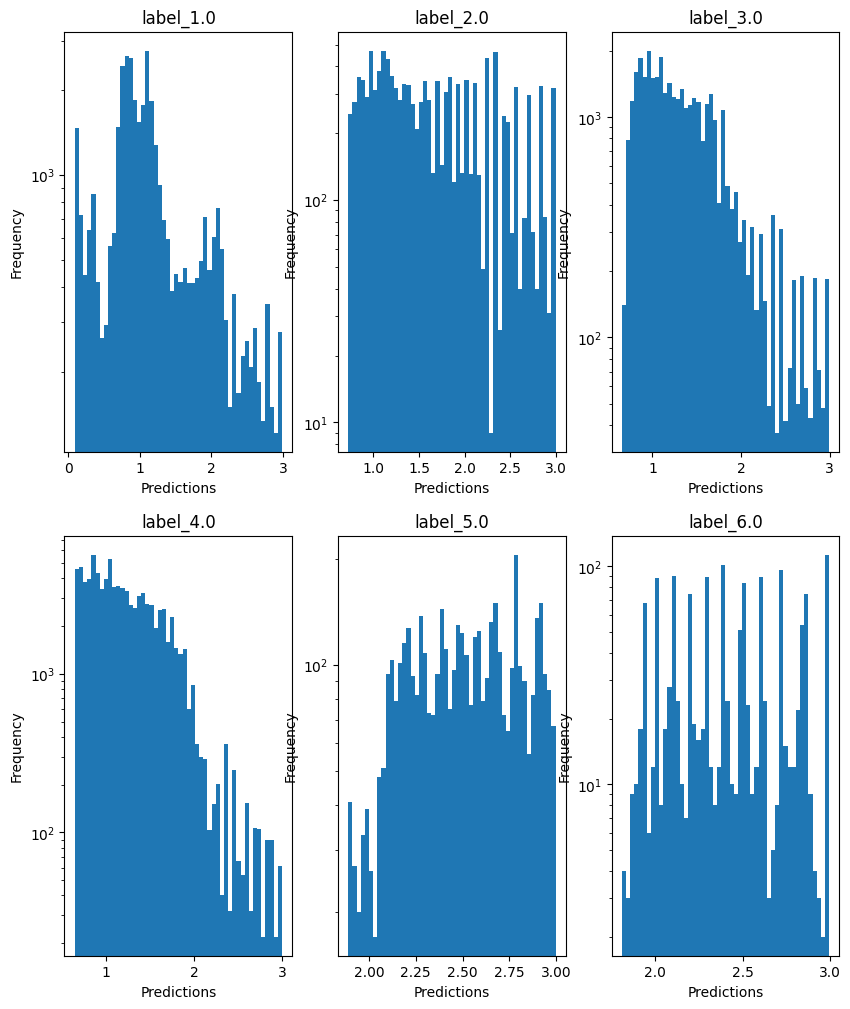

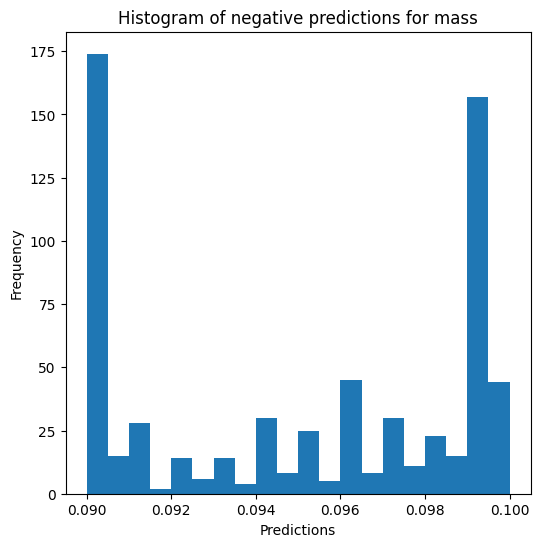


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9999412439590385
  RMSE :  0.0023033792816898086
  MAE :  0.0009226985690438245
  MedAE :  0.00013637080844383642
  CORR :  0.9999706236637507
  MAX_ER :  0.03568621407328659
  Percentiles : 
    75th percentile :  0.0007743570083589453
    90th percentile :  0.0026798812195893535
    95th percentile :  0.0047043574594961505
    99th percentile :  0.01045358386409771

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9998285415775119
  RMSE :  0.00319720709719808
  MAE :  0.0014626293337904371
  MedAE :  0.0002581941400820048
  CORR :  0.9999143299160497
  MAX_ER :  0.03288357547497678
  Percentiles : 
    75th percentile :  0.001433096853156405
    90th percentile :  0.0046336061524879036
    95th percentile :  0.00717514613004663
    99th percentile :  0.013355750685911867

radius re

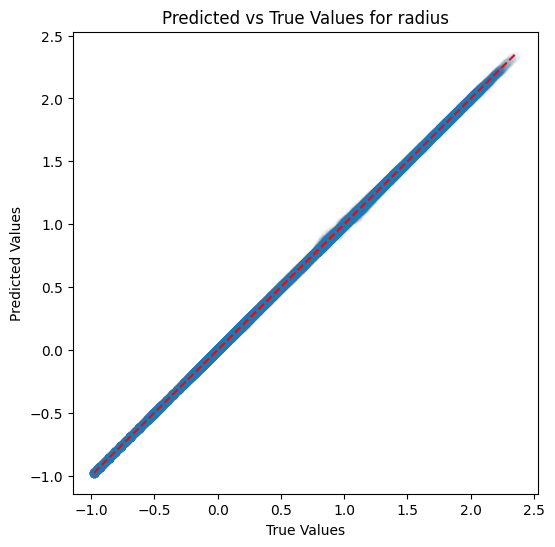

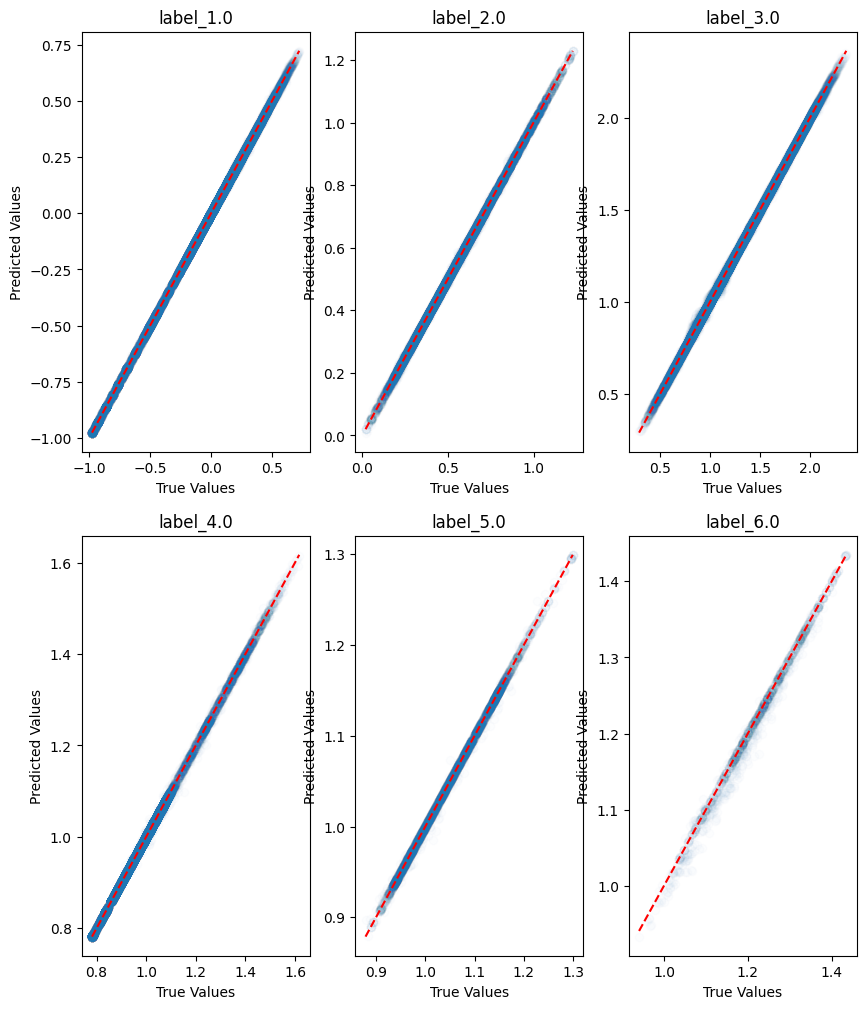

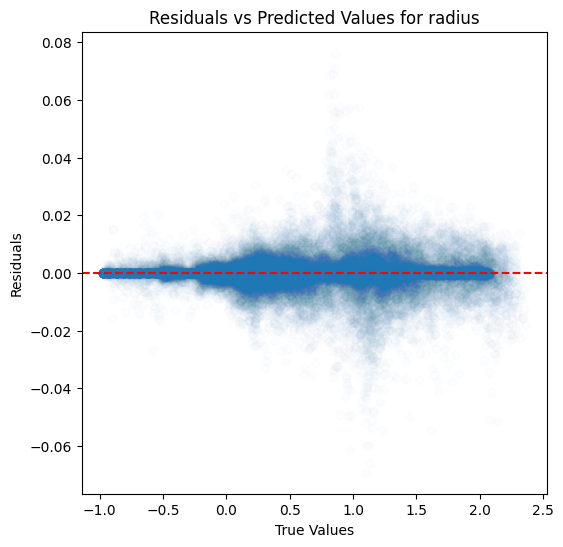

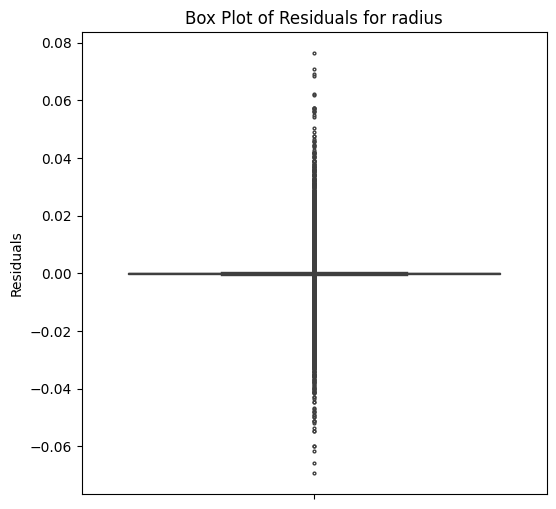

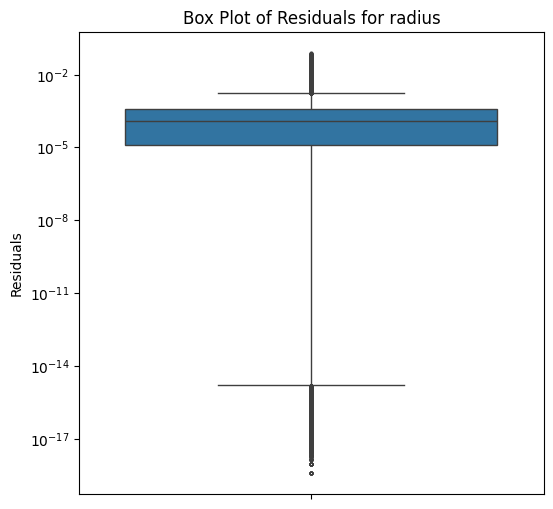

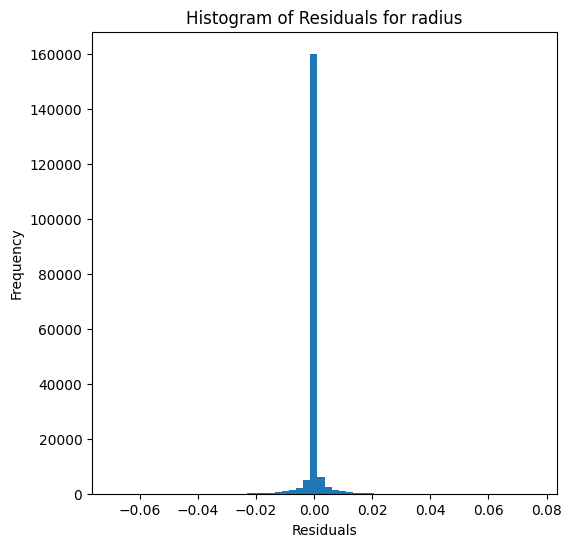

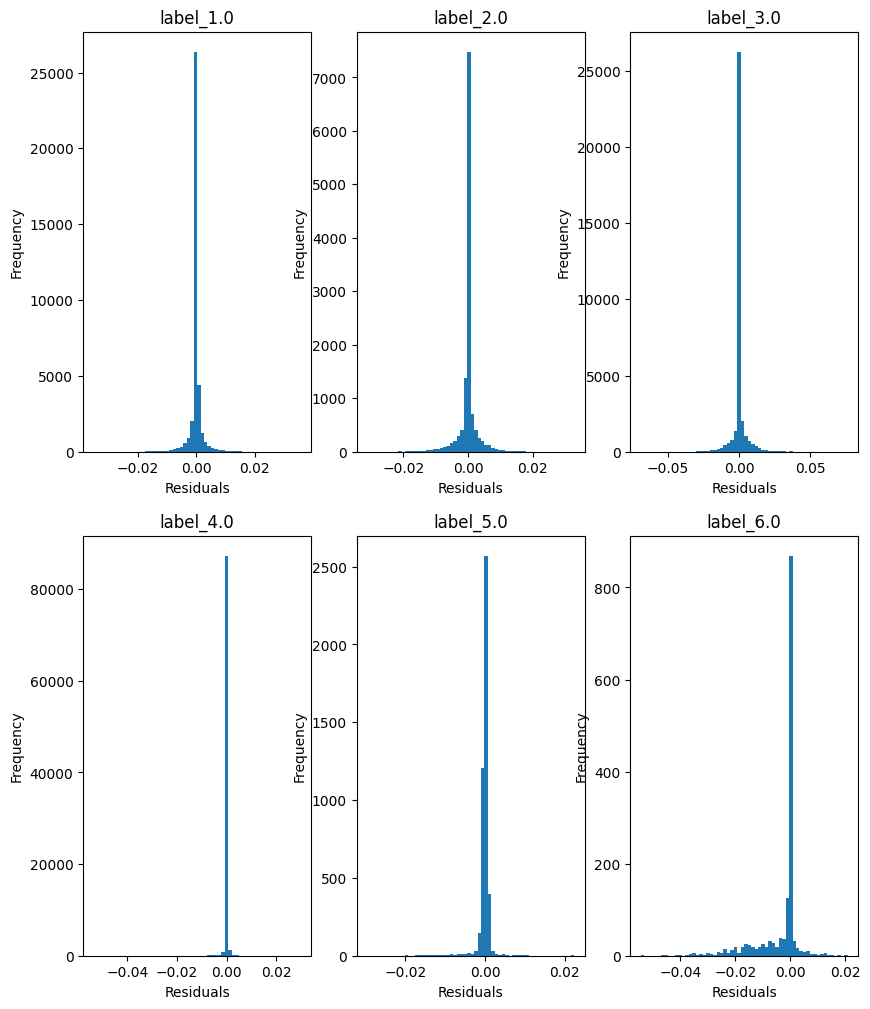

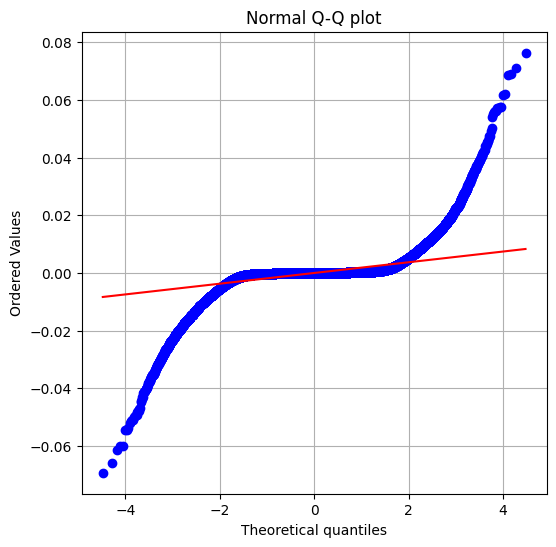

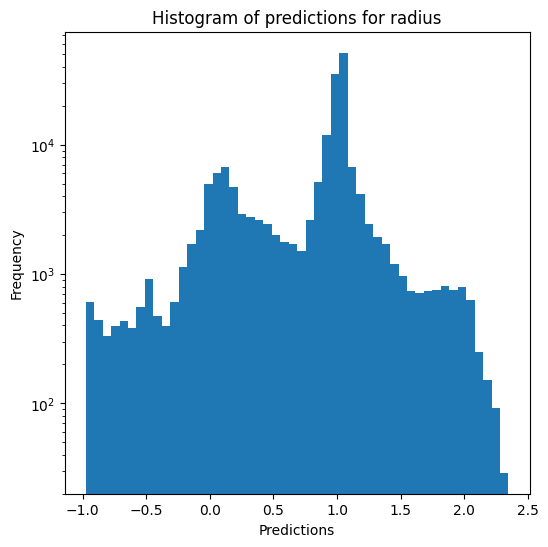

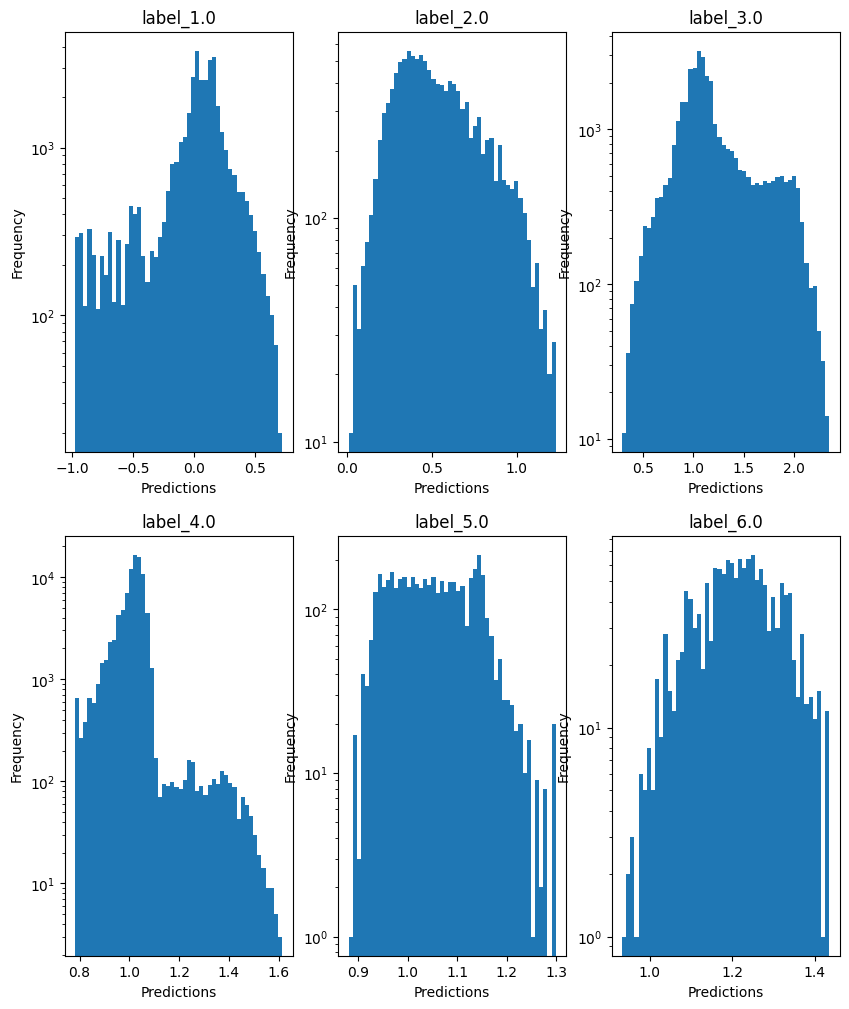

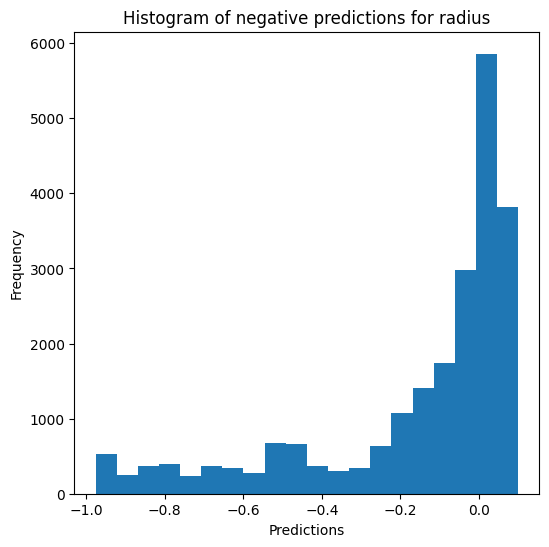

Saving predictions and results...


In [18]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### XGBoost

In [19]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_stand_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9989190774264869
  RMSE :  0.021113900039454164
  MAE :  0.012955817968592393
  MedAE :  0.007141310691833547
  CORR :  0.999460435153906
  MAX_ER :  0.23273415374755846
  Percentiles : 
    75th percentile :  0.016863574266433867
    90th percentile :  0.03170178642272957
    95th percentile :  0.04397313084602348
    99th percentile :  0.08148778570175157

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9997386147290966
  RMSE :  0.010224238799817249
  MAE :  0.006961948929617581
  MedAE :  0.0046716270446776065
  CORR :  0.9998695325352005
  MAX_ER :  0.09049644279479985
  Percentiles : 
    75th percentile :  0.008902166366577369
    90th percentile :  0.016306894302368313
    95th percentile :  0.022040017175674373
    99th percentile

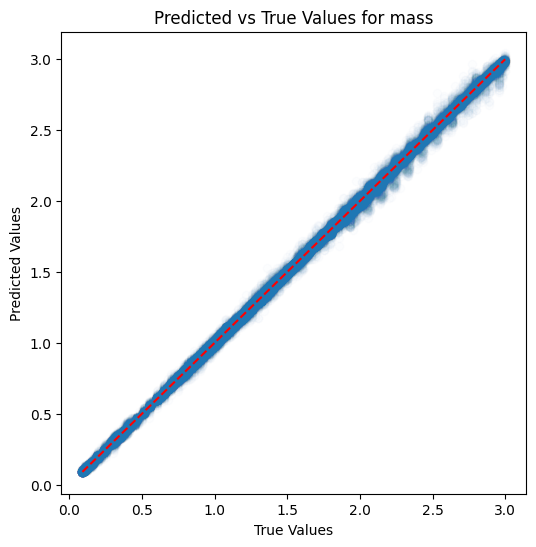

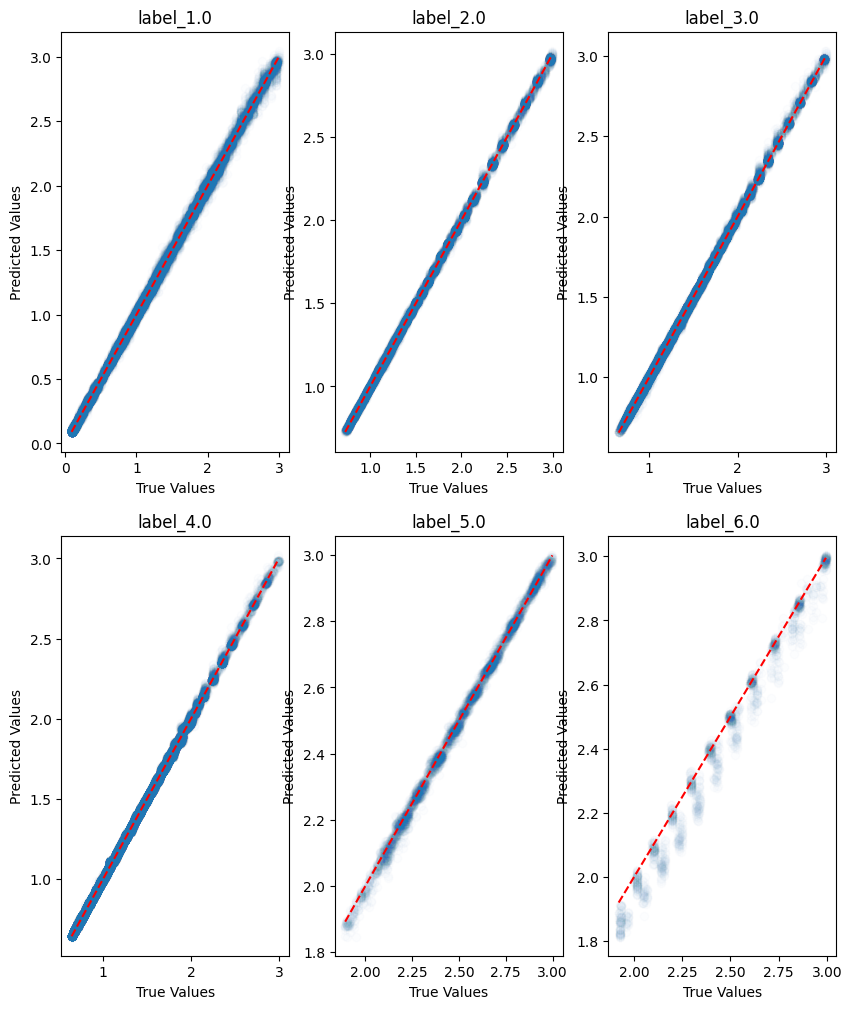

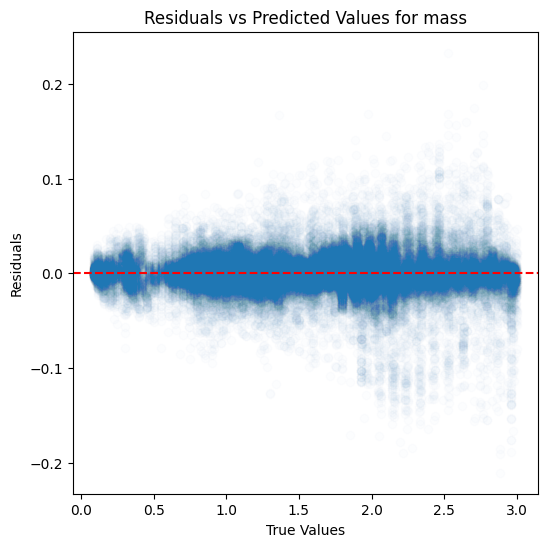

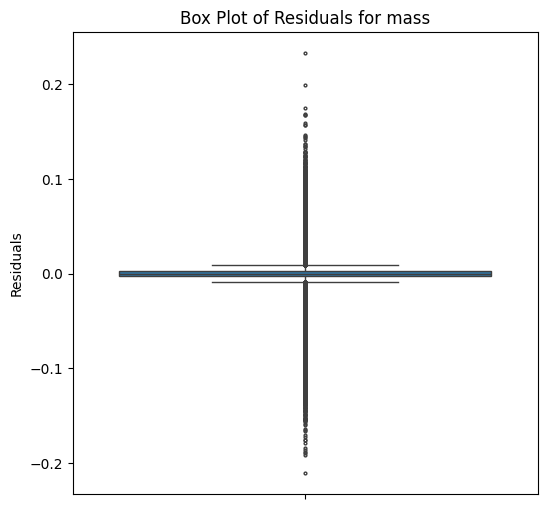

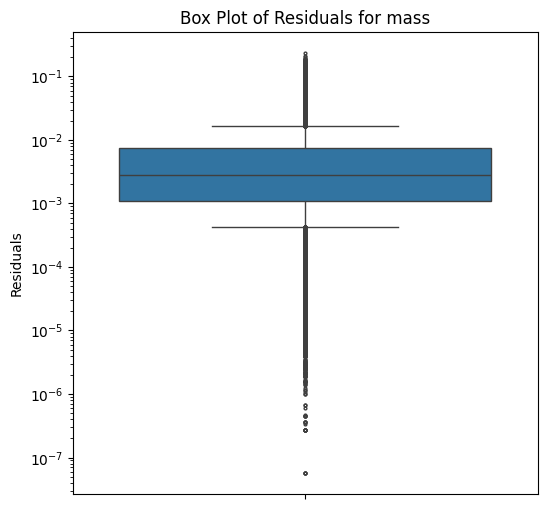

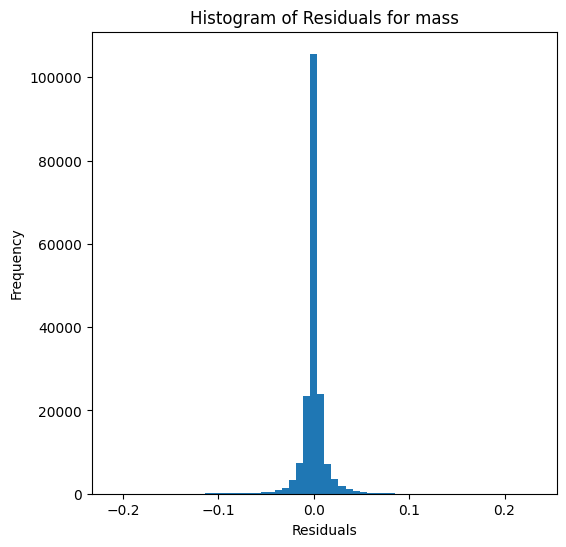

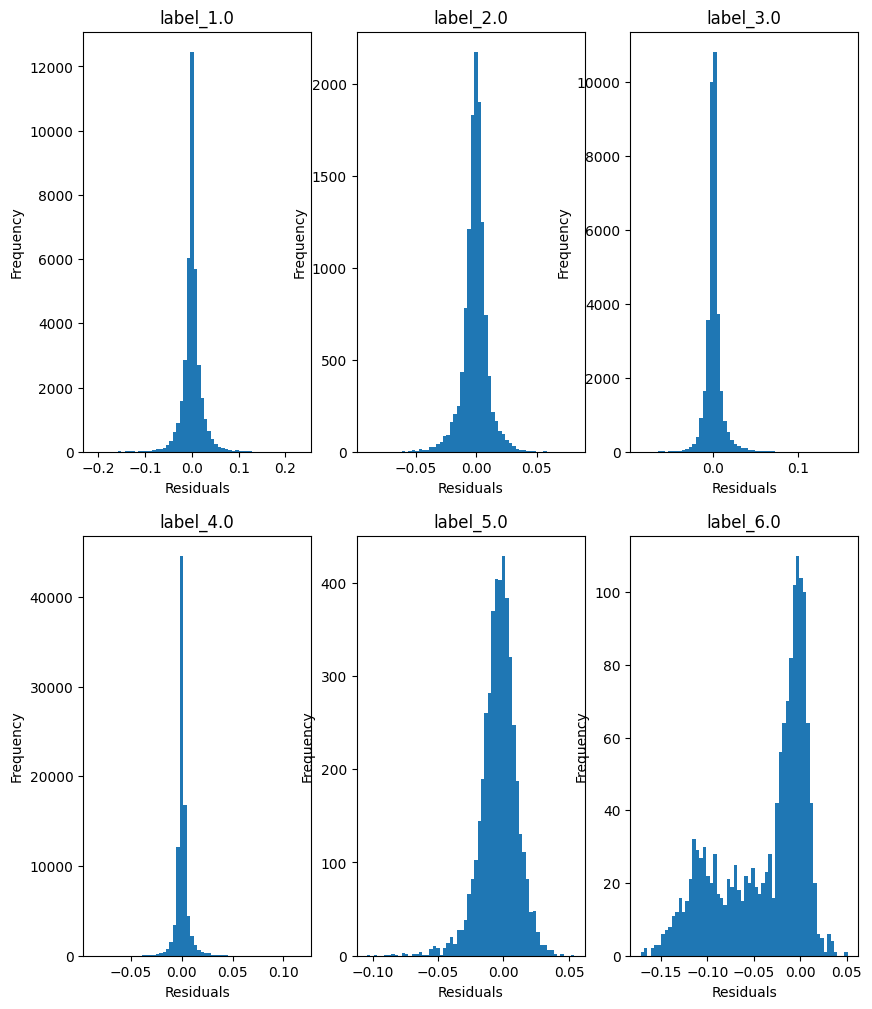

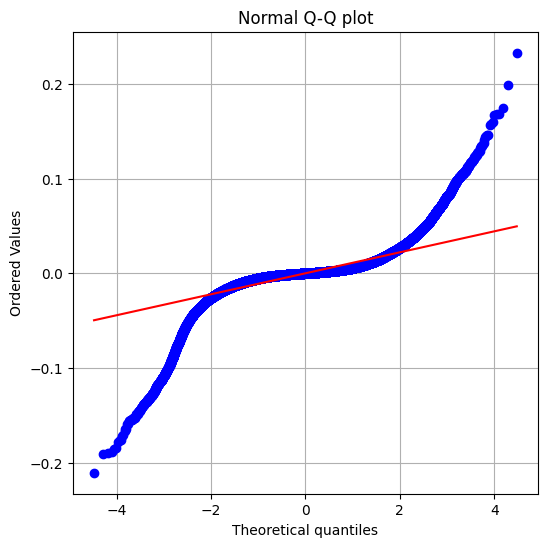

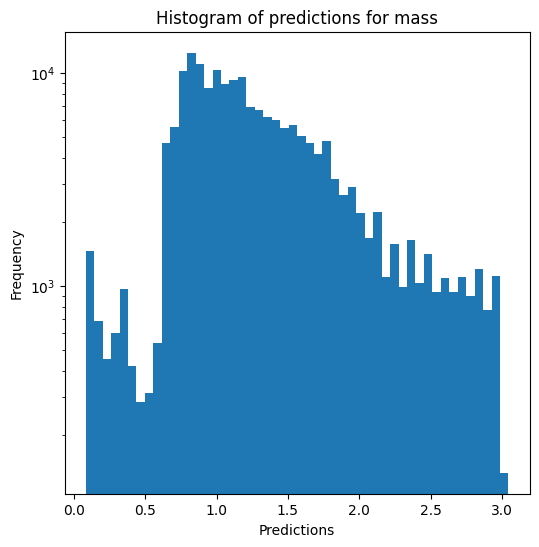

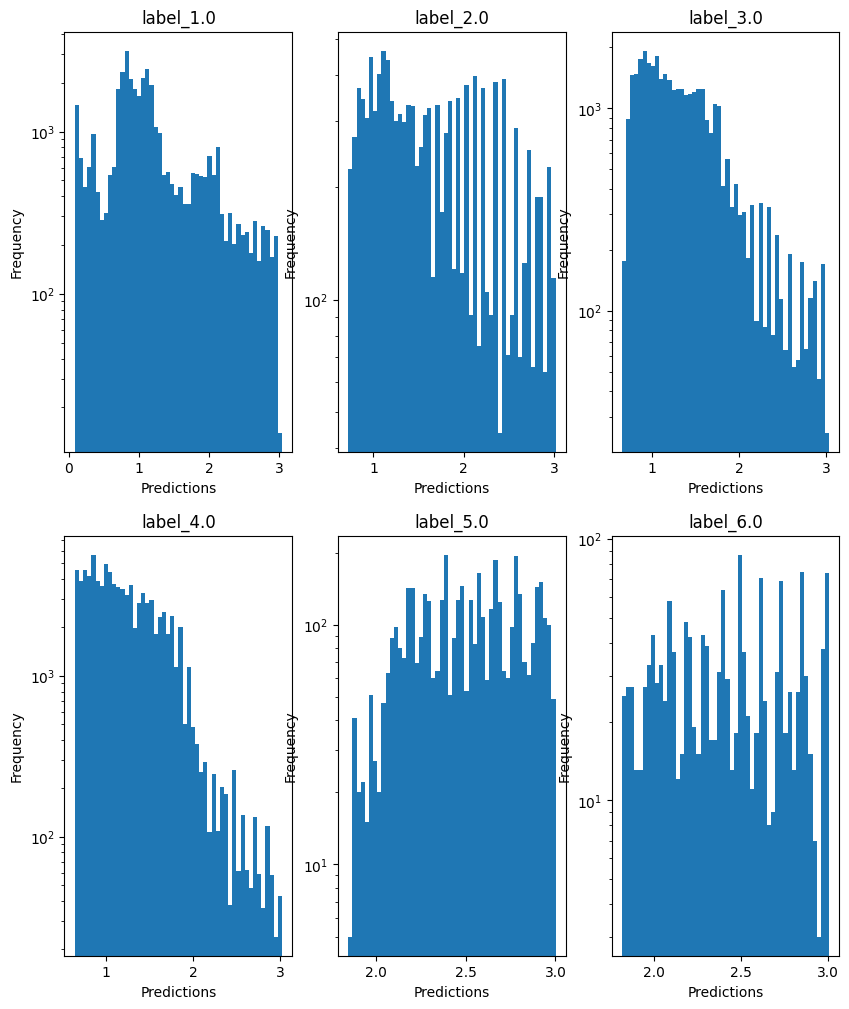

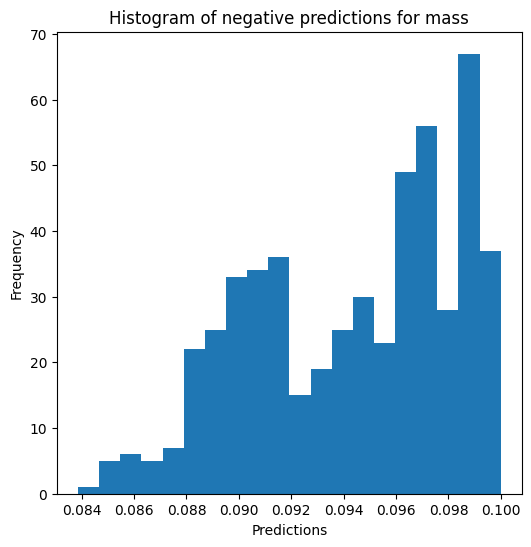


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9993147227108912
  RMSE :  0.00786467892100313
  MAE :  0.005198325227519067
  MedAE :  0.0034333127182981094
  CORR :  0.9996573327303526
  MAX_ER :  0.06827712710358969
  Percentiles : 
    75th percentile :  0.006730464485696034
    90th percentile :  0.01143777481045417
    95th percentile :  0.016100620052158943
    99th percentile :  0.02860042068562522

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9987323948124496
  RMSE :  0.008693723547433795
  MAE :  0.006917988282027232
  MedAE :  0.005892467958579839
  CORR :  0.9993660425000692
  MAX_ER :  0.040720456544565575
  Percentiles : 
    75th percentile :  0.009927378298236977
    90th percentile :  0.014242375528363705
    95th percentile :  0.016934818188078175
    99th percentile :  0.022639018099789562

radius results fo

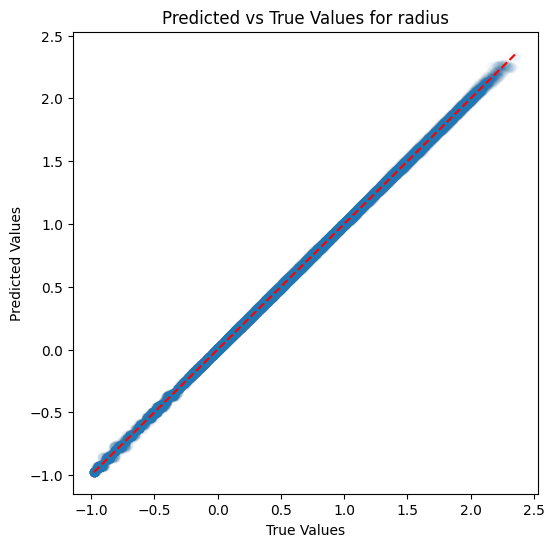

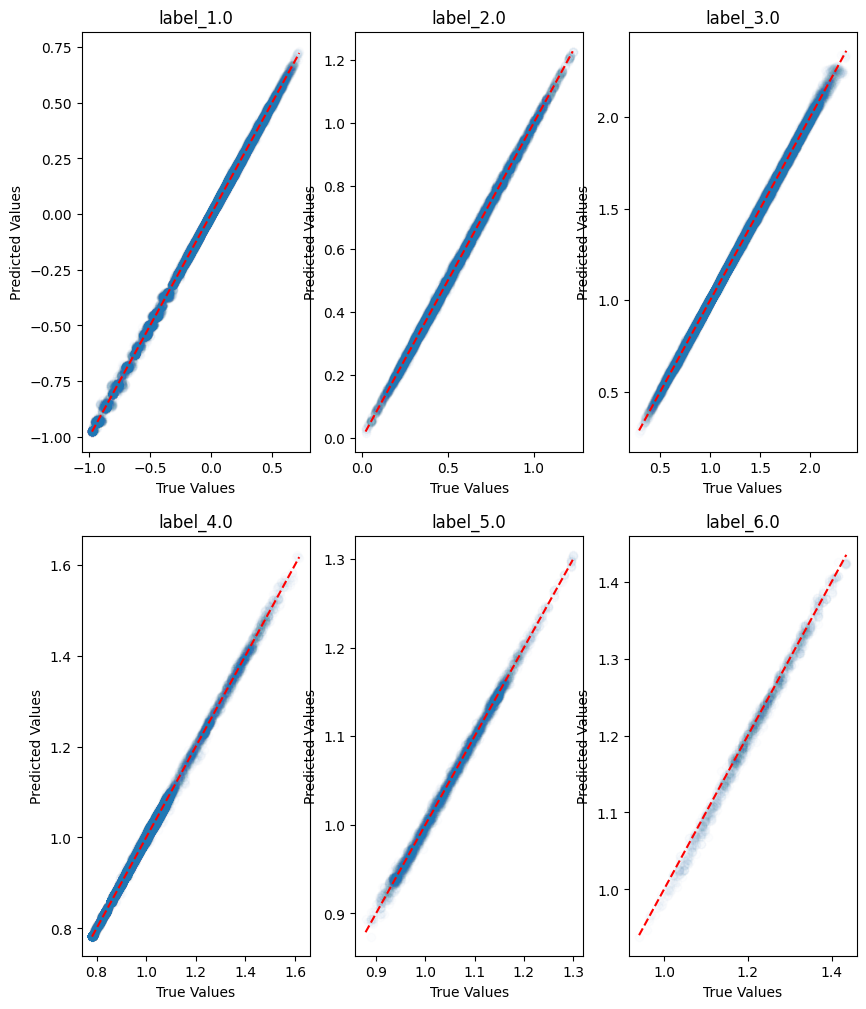

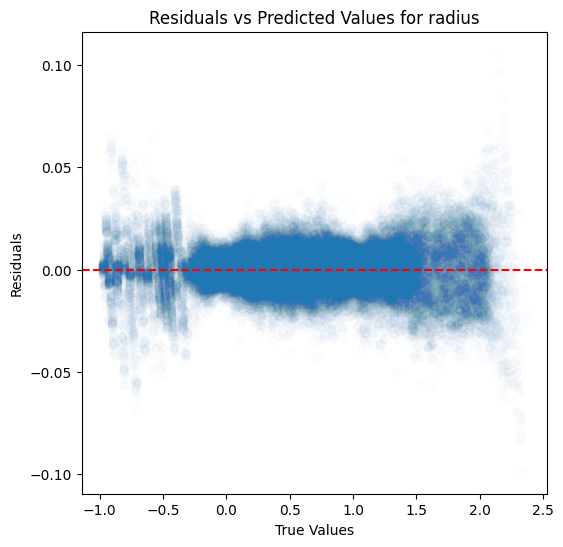

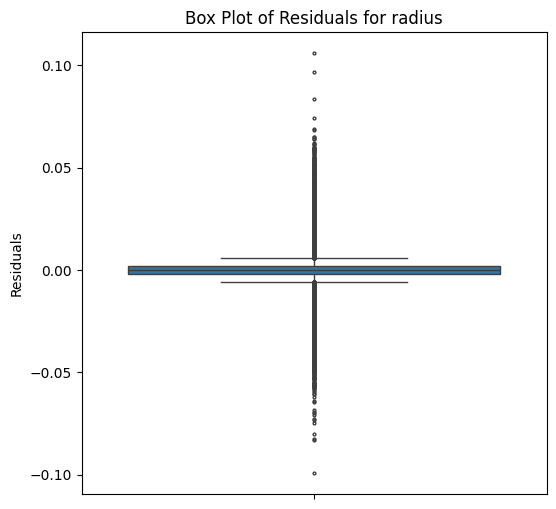

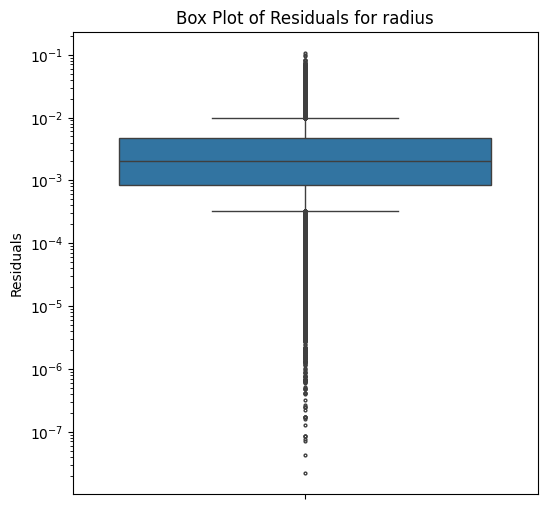

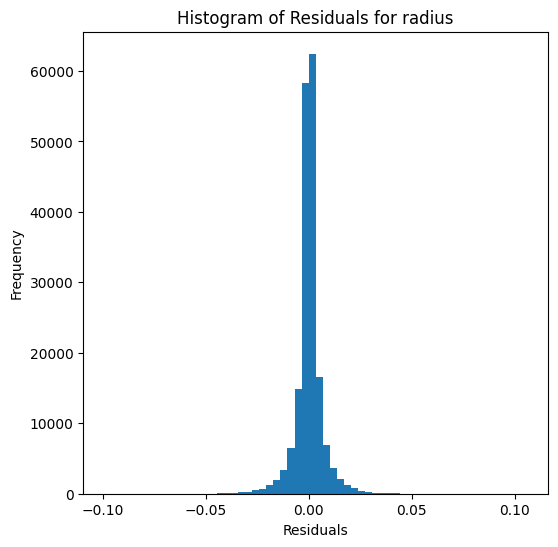

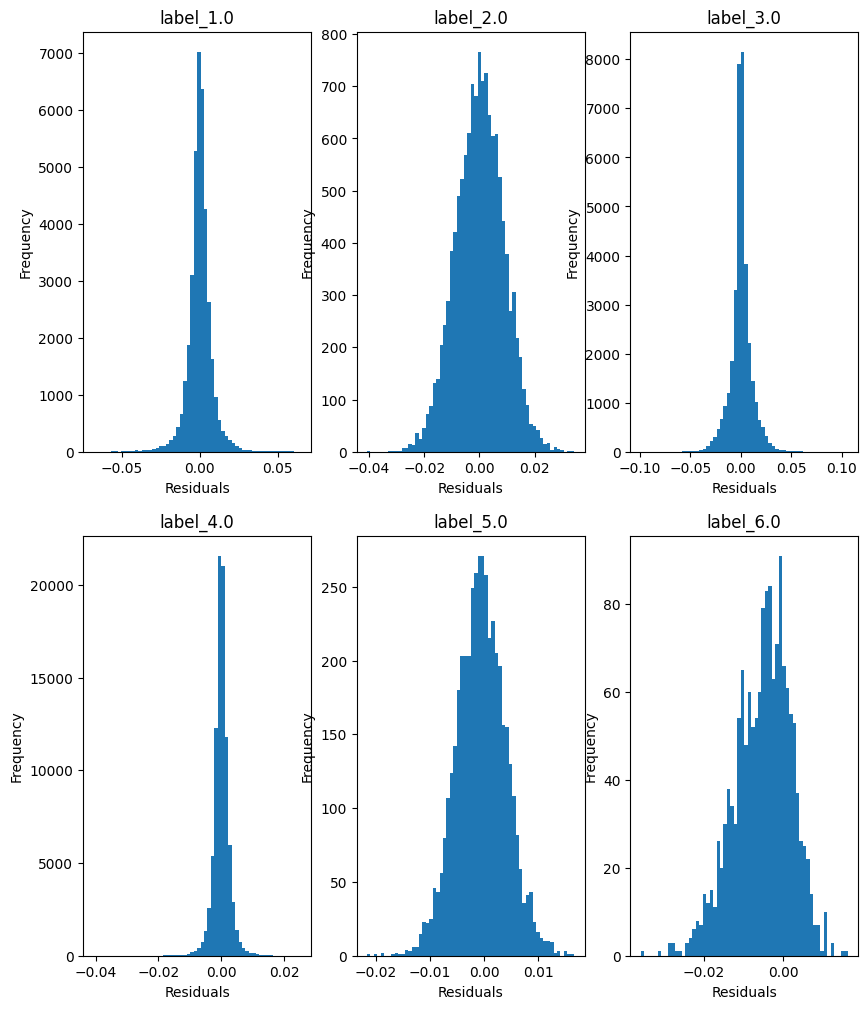

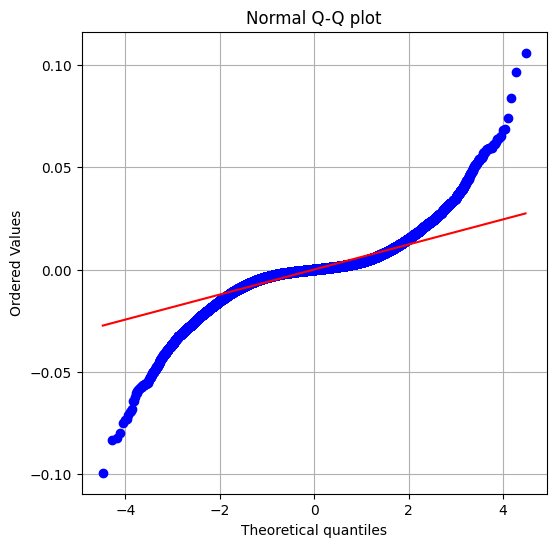

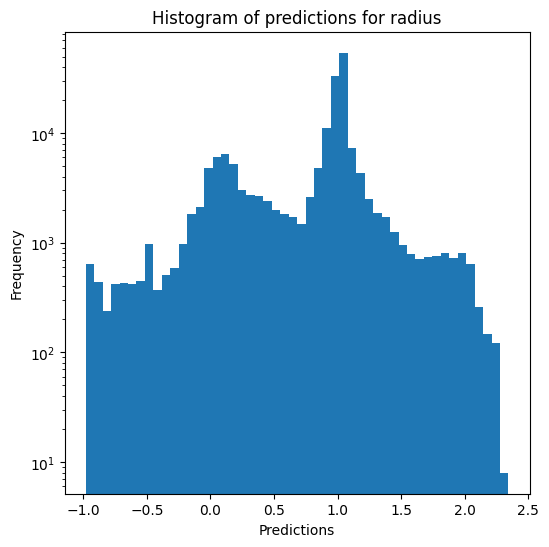

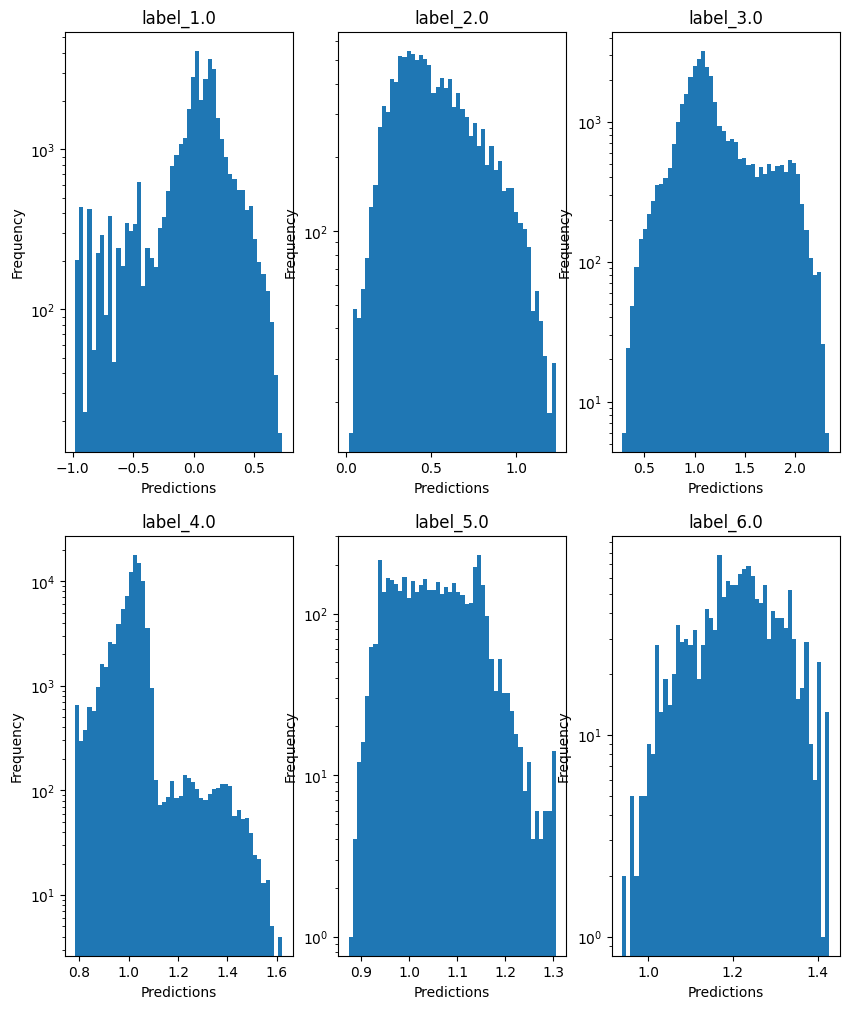

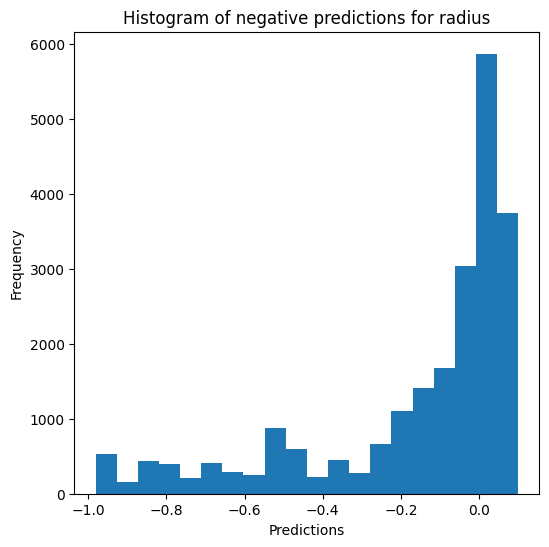

Saving predictions and results...


In [20]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [21]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_stand_3 train data :
Performing K-fold...
Split 1 8.224066090916409e-05
2 7.959140458487834e-05
3 8.131708038302822e-05
4 8.702068332832313e-05
5 9.126625730181367e-05

Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9997625988015316
  RMSE :  0.009894845843621436
  MAE :  0.007070991139924189
  MedAE :  0.0051537151689712846
  CORR :  0.999883217181347
  MAX_ER :  0.09292161471499094
  Percentiles : 
    75th percentile :  0.009450439674354806
    90th percentile :  0.015477881683497155
    95th percentile :  0.020190723853580894
    99th percentile :  0.032544568279185365

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.999636308662698
  RMSE :  0.012051276334156907
  MAE :  0.00871318707900162
  MedAE :  0.0064039510831639945
  CORR :  0.9998181470251718
  MAX_ER :  0.07952930986383056
  Percentiles : 
    75th percentile :  0.011746873146035341
    90

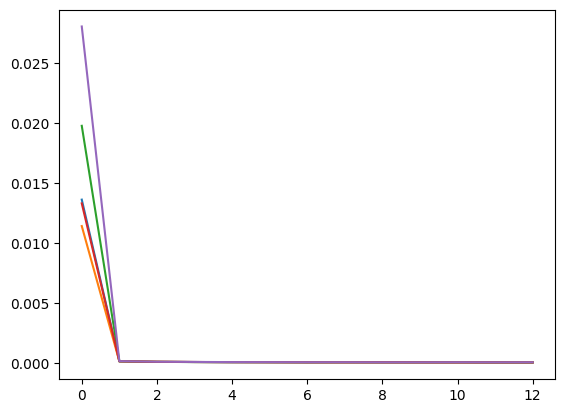

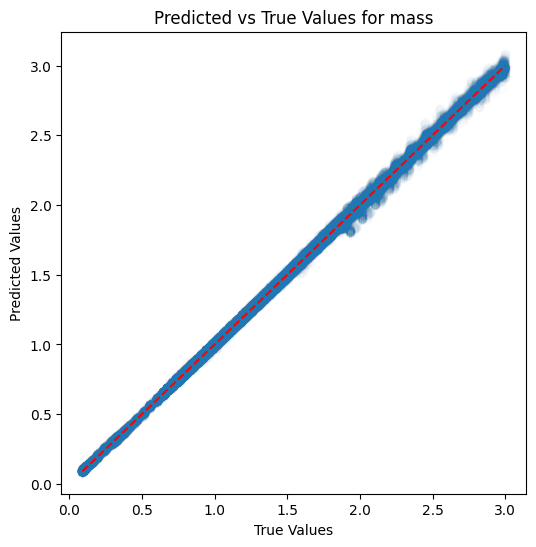

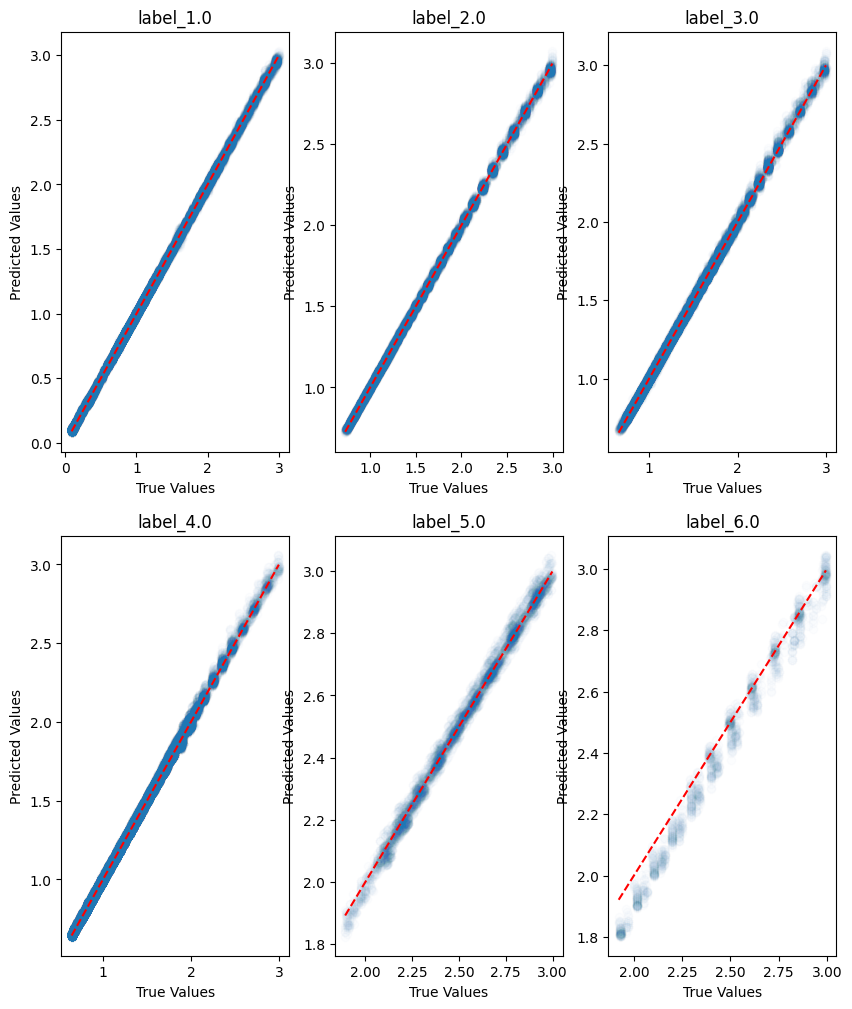

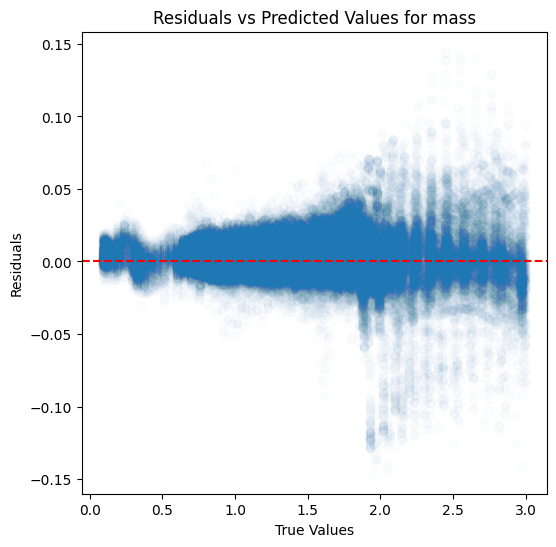

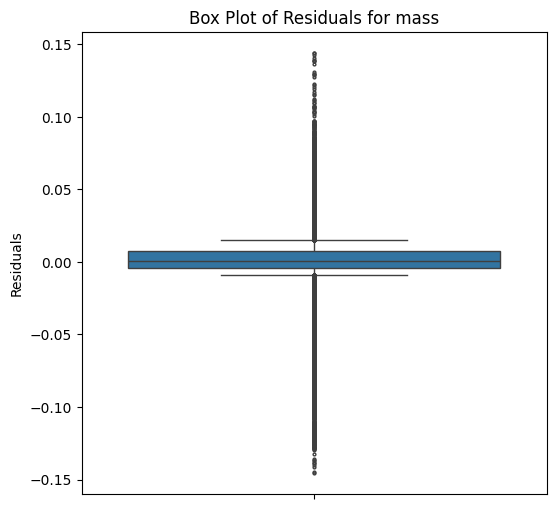

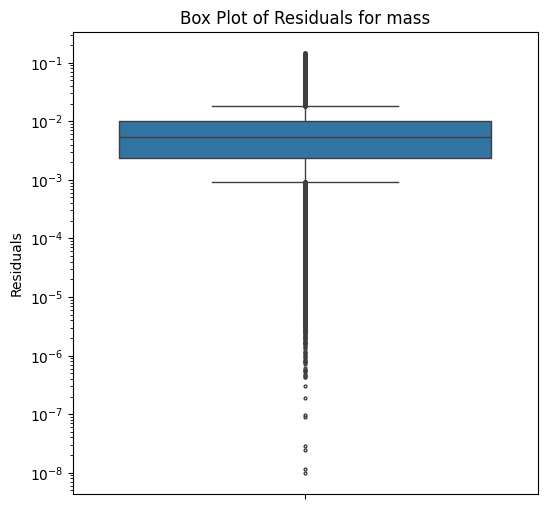

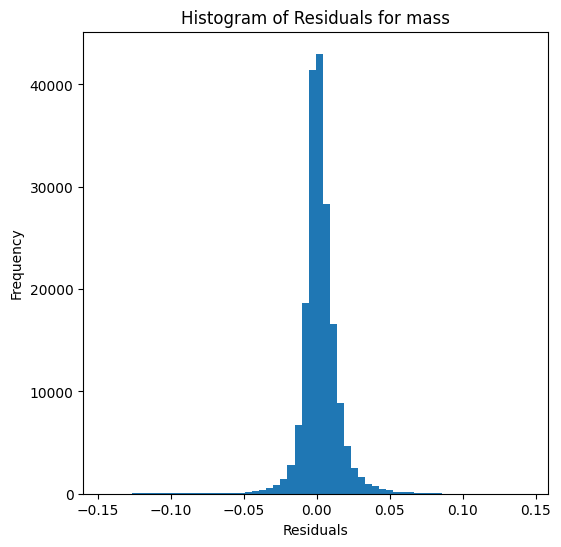

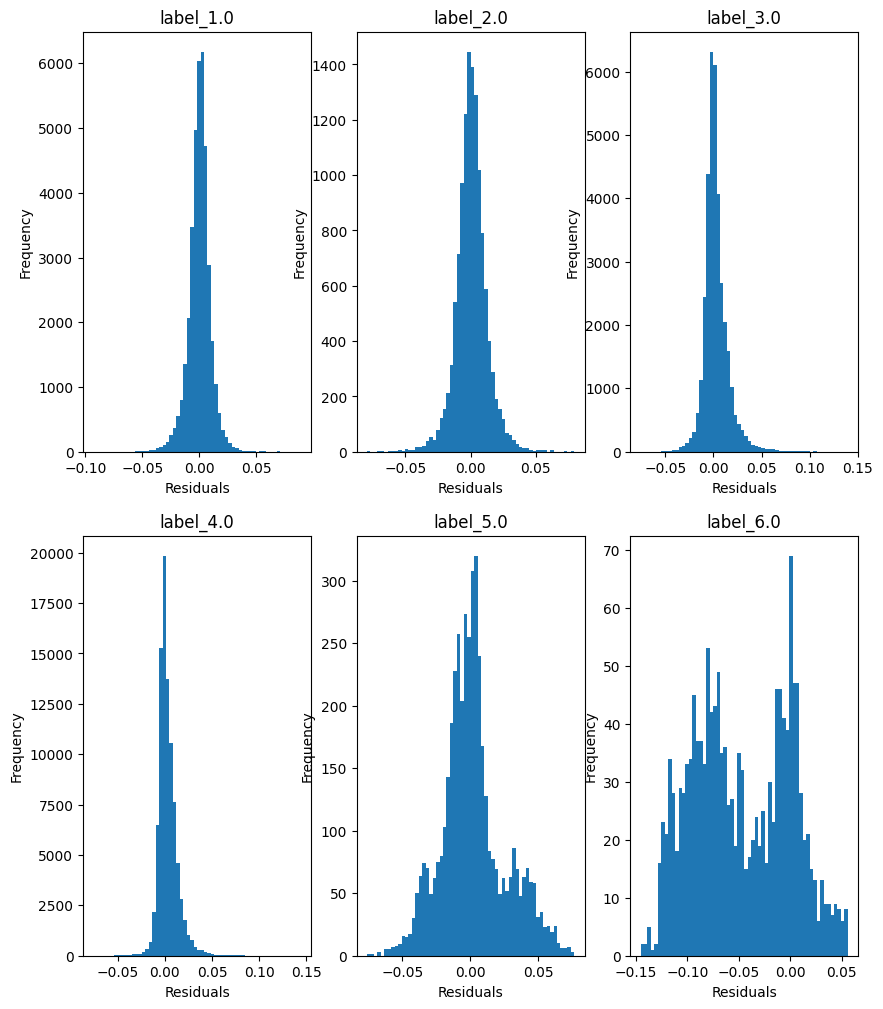

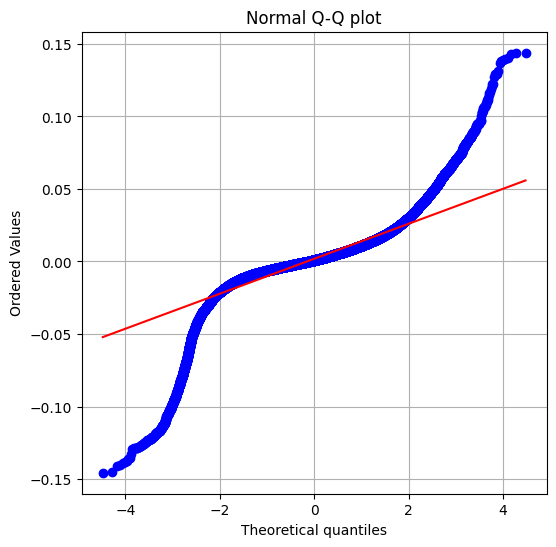

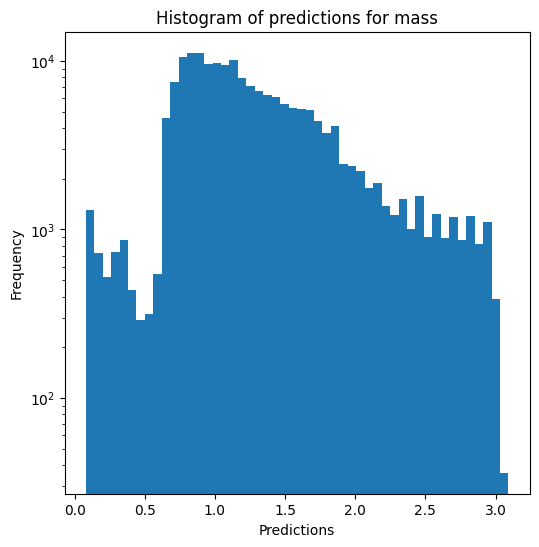

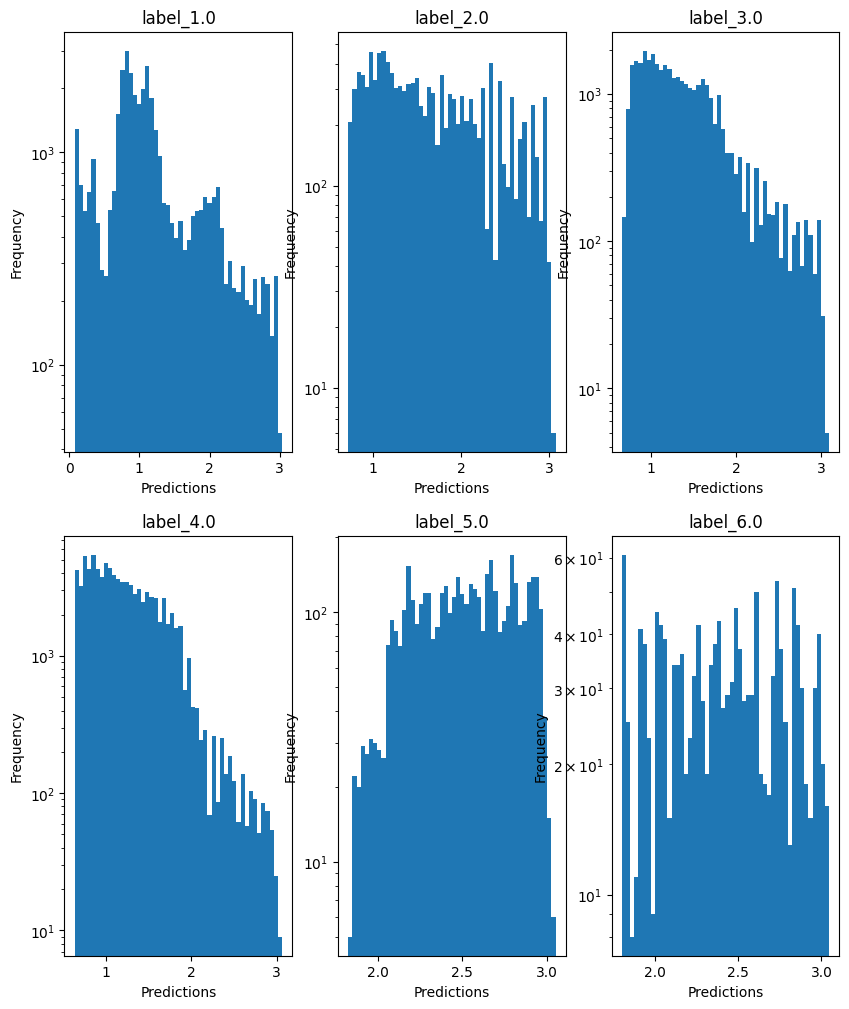

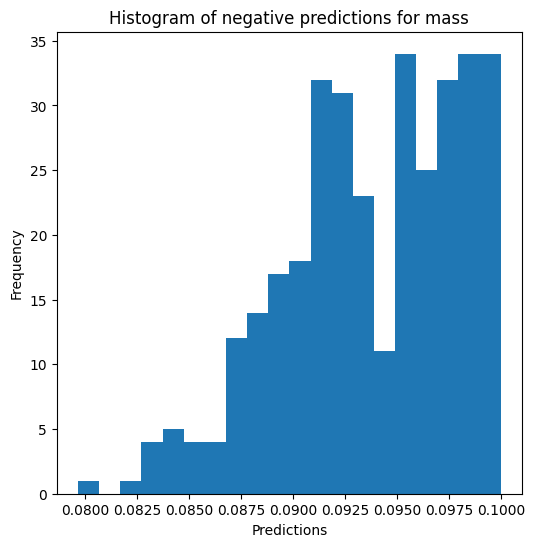


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9996223377237167
  RMSE :  0.006494159403319875
  MAE :  0.004896195130499114
  MedAE :  0.0038043446082867277
  CORR :  0.9998111982608258
  MAX_ER :  0.041517315028558766
  Percentiles : 
    75th percentile :  0.006724040398009737
    90th percentile :  0.010639420689363665
    95th percentile :  0.013528414722608037
    99th percentile :  0.019380188653954522

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9994890613083083
  RMSE :  0.006077487398852767
  MAE :  0.004811795464188621
  MedAE :  0.003969774220789091
  CORR :  0.9997447340606154
  MAX_ER :  0.028570716320150402
  Percentiles : 
    75th percentile :  0.006914715895536411
    90th percentile :  0.010062909203482863
    95th percentile :  0.011935530847983907
    99th percentile :  0.015961808117830347

radius result

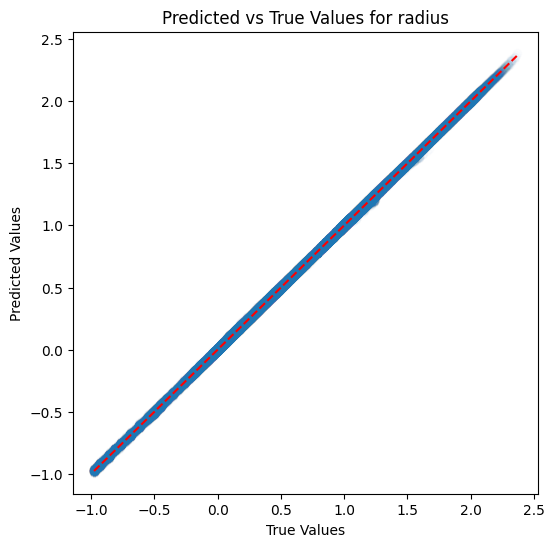

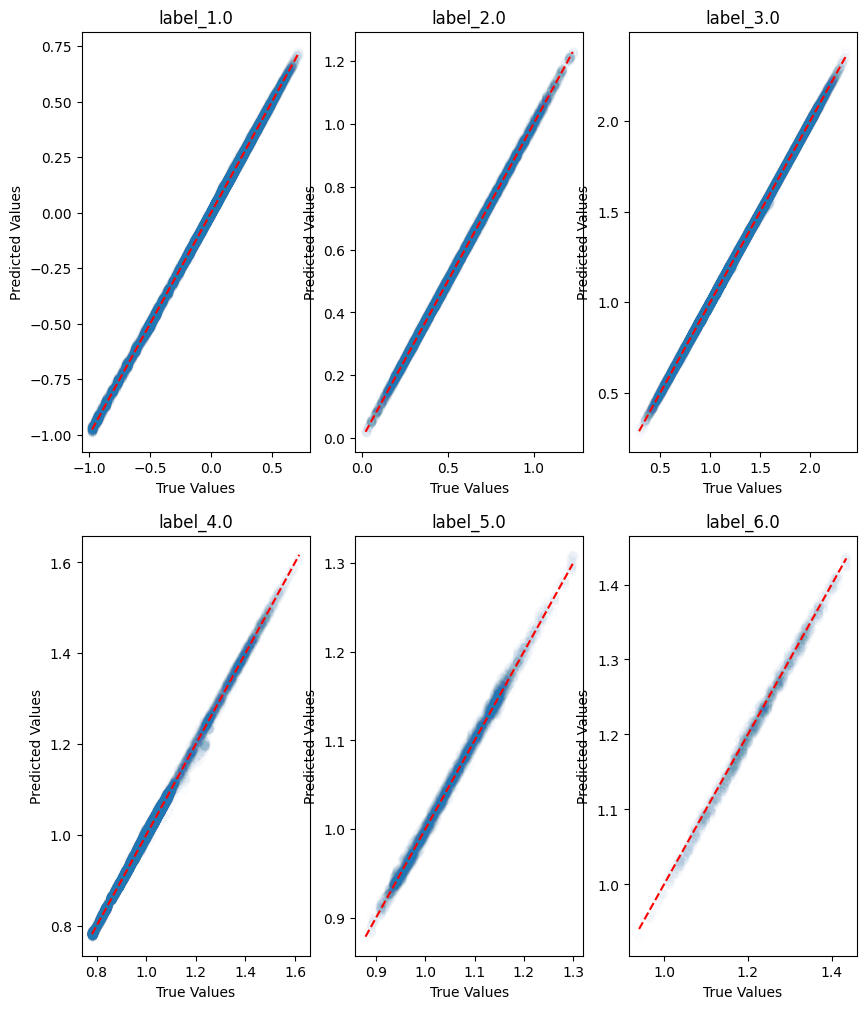

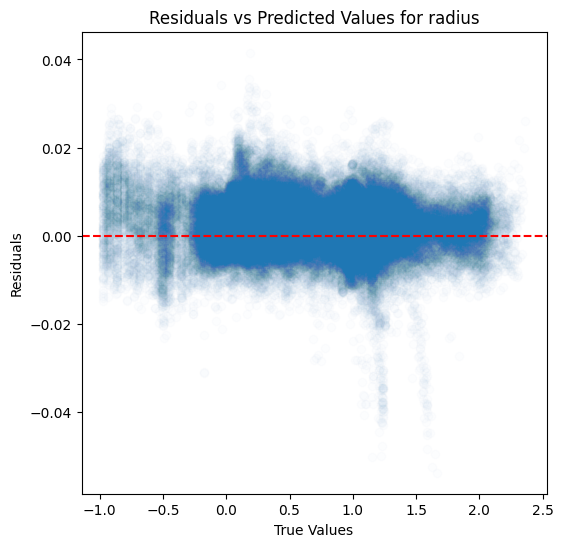

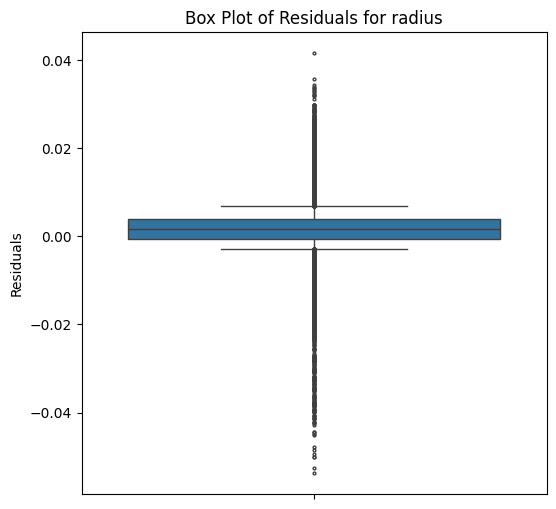

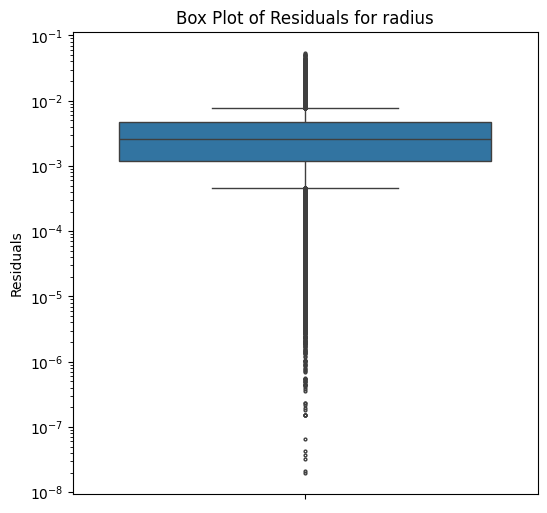

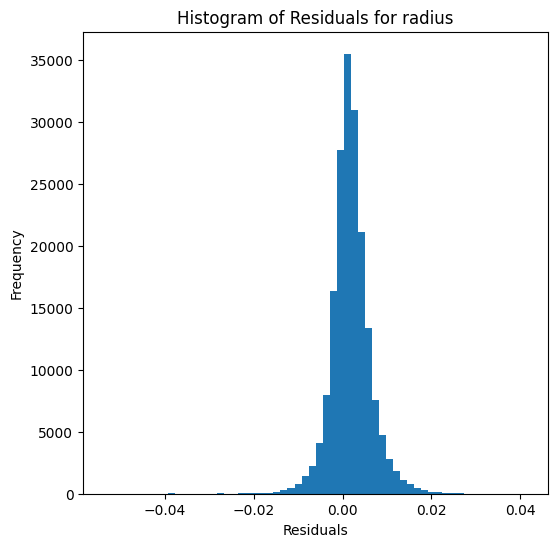

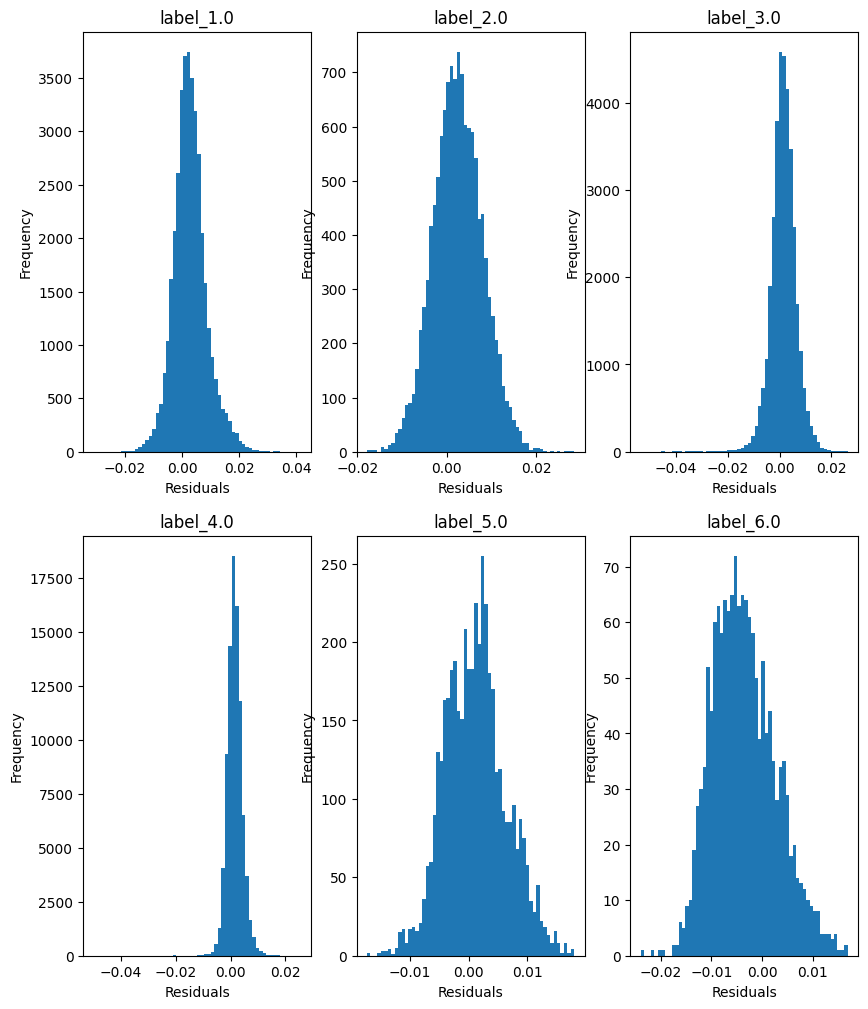

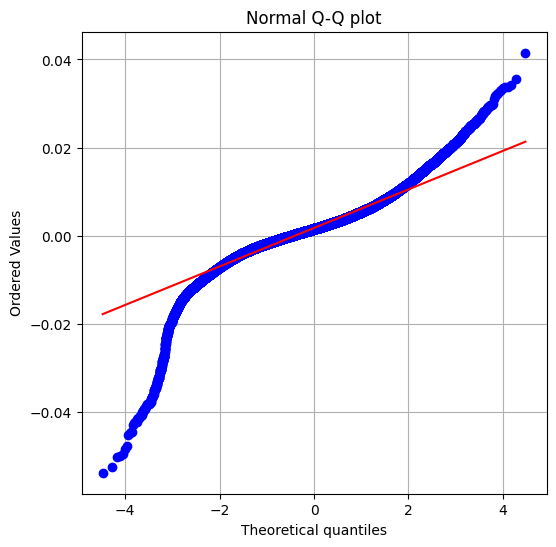

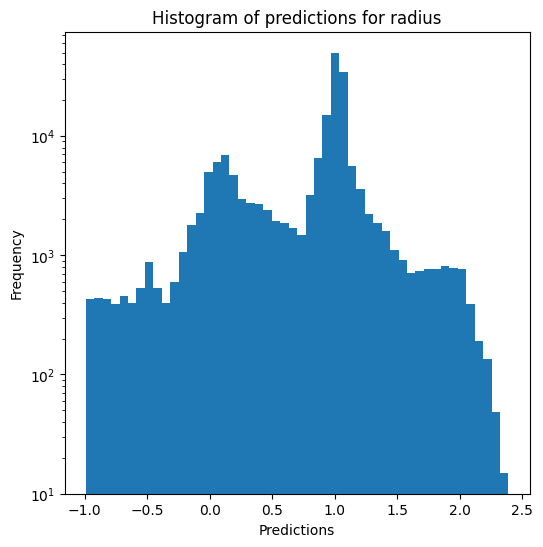

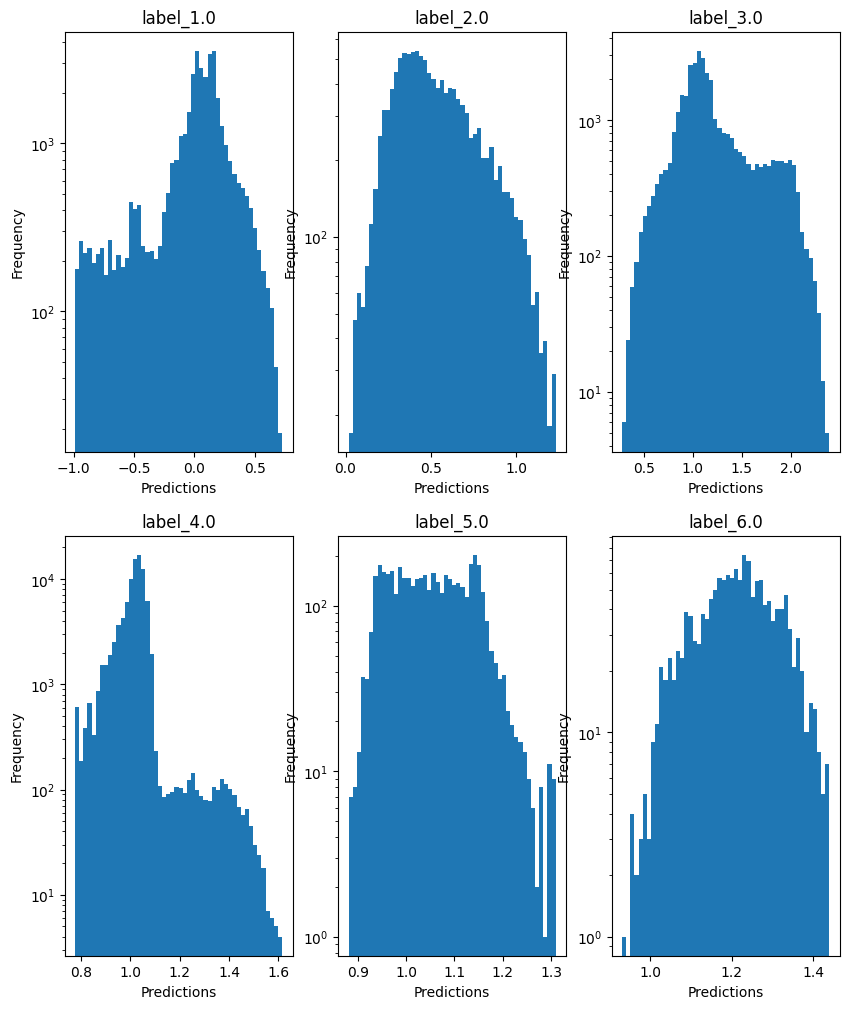

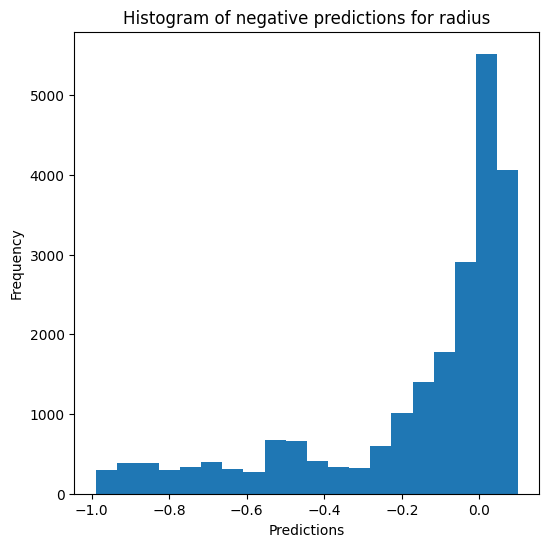

Saving predictions and results...


In [22]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, scaler_name=scaler_name, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)